**例5-35：DBSCAN聚类算法展示。**

>第一步，生成数据。这里使用<font color='red'>make_blobs()函数</font>构建3个合成的簇。

In [9]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(n_samples=750, centers=centers, cluster_std=0.4, random_state=0)

X = StandardScaler().fit_transform(X)

>第二步，生成数据标准化后可视化，进行绘图。

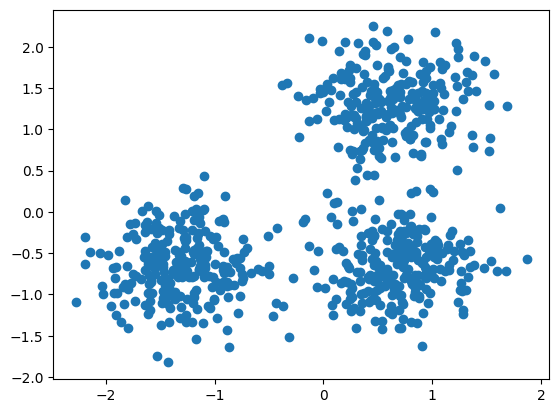

In [10]:
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

>第三步，执行DBSCAN。这里可以使用<font color='red'>labels_属性</font>访问DBSCAN分配的标签。噪声样本的标签为-1。

In [11]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)
labels = db.labels_
# 标签中的簇数，忽略噪声（如果存在）
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

Estimated number of clusters: 3
Estimated number of noise points: 18


<font color='red'>类算法基本上是无监督学习方法</font>。然而，由于make_blobs()可以访问合成聚类的真实标签，因此可以利用这种“监督”的真实值信息来量化生成聚类的质量。在此，使用的评估指标可以有<font color='red'>同质性、完整性、V-测度、兰德指数、调整后兰德指数和调整后互信息（AMI）</font>等。

如果真值标签未知，则只能使用模型结果本身进行评估。在这种情况下，轮廓系数就派上了用场。

In [12]:
print(f"Homogeneity: {metrics.homogeneity_score(labels_true, labels):.3f}")
print(f"Completeness: {metrics.completeness_score(labels_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(labels_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(labels_true, labels):.3f}")
print("Adjusted Mutual Information:" f" {metrics.adjusted_mutual_info_score(labels_true, labels):.3f}")
print(f"Silhouette Coefficient: {metrics.silhouette_score(X, labels):.3f}")

Homogeneity: 0.953
Completeness: 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Adjusted Mutual Information: 0.916
Silhouette Coefficient: 0.626


>第四步，绘制结果。核心样本（大点）和非核心样本（小点）依据指定的聚类进行颜色编码。标记为噪波的样本以黑色表示，进行绘图。

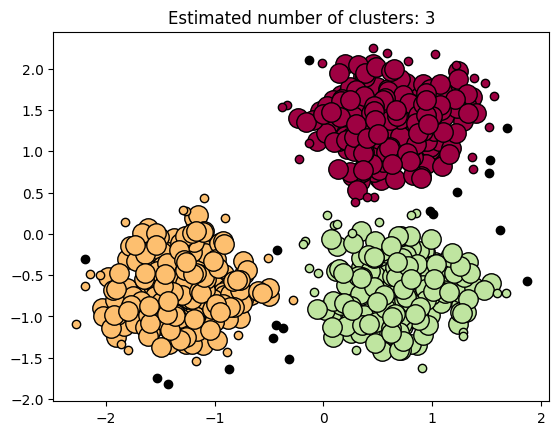

In [13]:
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]  # 黑点表示噪声
        
    class_member_mask = labels == k
	
    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=14,)
	
    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], "o", markerfacecolor=tuple(col), markeredgecolor="k", markersize=6,)

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

<div style="text-align: center;">层次聚类汇集树

<font color='red'>DBSCAN算法</font>是确定性的，当以相同的顺序给定相同的数据时，总是生成相同的簇。然而，当以不同的顺序提供数据时，算法结果可能会有所不同。**首先**，即使核心样本总是被分配给相同的簇，但这些簇的标签也将取决于数据提供中遇到这些样本的顺序。**其次**，也是更重要的一点，非核心样本所分配到的簇可能因数据提供顺序而异。当一个非核心样本与不同簇中的两个核心样本的距离小于eps时，就会发生这种情况。根据<font color='red'>三角不等式</font>，这两个核心样本之间的距离必须比eps大，否则它们将在同一簇中。非核心样本被分配给在数据聚类过程中首先生成的簇，因此结果取决于数据提供顺序。  

当前的DBSCAN算法实现使用ball-树和kd-树来确定点的邻域，这避免了计算全距离矩阵，保留了使用自定义度量的可能性。

### <font color='blue' >5.7.6  算法小结</font>

通过本节内容讲解，读者可以大致知道一些聚类算法及其使用方法，理解各聚类算法的步骤。<font color='red'>KMeans算法</font>作为一种通用目的聚类算法，其度量是基于样本点之间的几何距离，该算法应该可以作为聚类方法的起点。<font color='red'>MiniBatchKMeans算法</font>是KMeans算法的一个变体，其主要目的是通过小批量样本的使用减少计算时间。<font color='red'>AP算法</font>通过在样本对之间发送消息实现聚类。<font color='red'>该算法的优点是不需要事先指出明确的簇数量。AP算法的主要缺点是训练速度较慢，且需要大量内存，因此也就很难扩展到大数据集中。另外，该算法同样假定潜在的簇是类球状的。</font><font color='red'>层次聚类</font>是一类通过依次合并或拆分构建嵌套聚类的算法。<font color='red'>该算法的主要优点是其不再需要假设簇为类球状，它也可以扩展到大数据集。该算法的主要缺点是需要设定聚类的数量。</font><font color='red'>DBSCAN算法</font>是一个基于密度的算法，它将样本点的密集区域组成一个簇。<font color='red'>该算法的优点有其不需要假设簇为类球状，并且它的性能是可扩展的。此外，它不需要每个点都被分配到一个簇中，这降低了簇的异常数据。DBSCAN算法的缺点是用户需要调整epsilon和min_sampl超参数，DBSCAN算法对这些超参数非常敏感。</font>

## <font color='blue' >5.8　本章小结</font>

本章自回归问题、分类问题和聚类问题展开讨论，引入若干算法，使读者能够初步了解各算法及其特点，基本知道算法的适用场景，哪种场景使用哪些方法，以及各算法的优化要素组成。自简入繁地讲解了单模型算法，<font color='red'>单模型包括线性回归、逻辑回归、朴素贝叶斯、最近邻算法、支持向量机、决策树和聚类算法等</font>。虽然本书尽可能地给出每种方法的基本理论、拓展，但更多聚焦于它们的工程实践和使用技巧上。但由于篇幅限制，以上每个算法均有更多的概念和细节没有展现出来，感兴趣的读者可以参阅相关资料以深入理解这些算法的细节，本章内容仅仅为读者提供了一个窗口。

## <font color='blue' >课后习题</font>

>1．什么是机器学习？机器学习的步骤和组成要素是什么？ 

>2．选择一个数据集，遵循机器学习步骤，分别使用线性回归、逻辑回归、朴素贝叶斯、最近邻算法、支持向量机、决策树和聚类等算法构建模型并进行训练，比较各算法的优劣。

    
# <font color='blue' > 第6章 集成学习算法</font>
<p style="line-height: 1.5;">
<details>
    <summary><font color='blue' size='4'>教学目标 </font></summary>
    <p style="line-height: 1.5;"> 通过集成学习算法的学习，读者可在迭代优化过程中强化工匠精神，在集成学习过程中树立团队意识，培养协作能力，在概率校准学习过程中培养耐心、细致和有条理的工作作风。</p>
</details>
<details>
    <summary><font color='blue' size='4'>教学内容：</font></summary> 
    
（1）集成学习的基本步骤。  
（2）集成学习中的偏差和方差。  
（3）Bagging元估计器。  
（4）随机森林。  
（5）AdaBoost算法。  
（6）GBDT算法。  
（7）基于直方图的梯度提升。  
（8）堆叠泛化。  
（9）概率校准。   
   </details>

</p>

## <font color='blue' >6.1　集成学习能带来什么
本节先介绍集成学习的策略及其主要步骤，然后讨论如何改进集成学习。
<p style="line-height: 1.5;">



当系统中都是同种类型的学习器时，我们称其为<font color='red'>同质（Homogeneous）系统</font>，同质系统中的个体学习器被称为基学习器，相应的学习算法被称为基学习算法。当系统中存在不同类型的学习器时，我们称其为<font color='red'>异质（Heterogeneous）系统</font>。由于异质集成中的个体学习器通常是由不同的学习算法训练生成的，因此称其为<font color='red'>组件学习器</font>。
在实际工作中，用得较多的是<font color='red'>同质学习器<font>。同质系统中的集成方法按照个体学习器间是否存在依赖关系可进一步分为以下两类：

- 个体学习器之间不存在强依赖关系的平均方法（如果应用于分类问题，则是投票方法），一系列个体学习器可以独立并行学习，对其预测值进行平均（分类问题中将获得最多选票的结果作为最终结果）。通常而言，平均组合（投票组合）估计器比任何单个基估计器都要好，因为它的方差减小了，代表算法有<font color='red'>Bagging</font>和<font color='red'>随机森林（Random Forest）</font>等。  
- 个体学习器之间存在强依赖关系的提升方法，也称为<font color='red'>Boosting方法</font>，一系列个体学习器按序串行生成，将前一个学习器的结果输出到下一个学习器中，将所有基学习器的输出结果相加（或采用更复杂算法的融合，如把各基分类器的输出作为特征，使用逻辑回归作为融合模型进行最后结果的预测）作为最终输出。该策略试图减少组合估计器的偏差，代表算法有<font color='red'>AdaBoost、Gradient Tree Boosting</font>等。

### <font color='blue' >6.1.1  集成学习的基本步骤</font>

由前述可知，集成学习过程大致可细分为3个步骤。下面以**Adaboost算法**为例，说明**基分类器训练和合并**的基本步骤。注意：这里主要是理解集成学习的基本步骤，算法的具体内容详见后面相应章节。

- **第一步**，<font color='red'>确定误差互相独立的基学习器</font>。这里选取<font color='red'>ID3决策树</font>作为基分类器。事实上，任何分类模型都可以作为基分类器，树形模型由于结构简单且较易产生随机性而比较常用。

- **第二步**，<font color='red'>训练基分类器</font>。假设训练集为$\{x_i,y_i\},i=1,2,\ldots,N$，其中$y_i\in\{-1,1\}$，并且有个基分类器，则可以按照如下过程来训练基分类器。

（1）初始化样本权重分布 $D_1\left(i\right)=1/N$ 。  

（2）for&ensp; $t=1,2,...,T$ &ensp;do

- 从训练集中，按照 <font color='red'>$D_t$ 分布</font>取<font color='red'>样本子集 $S_t=\{x_i,y_i\},i=1,2,\ldots,N_t$ </font>。
- 使用 $S_t$ 训练<font color='red'>基分类器 $h_t$ </font>。
- 计算 <font color='red'>$h_t$ 的错分率</font>：$\epsilon_t=\frac{\sum_{i=1}^{Nt} I{\,}\left[
{\,}{h_t}{\,}\left({x_i}\right){\,}\neq{\,}y_i{\,}\right]{\,}D_t{\,}\left(X_i\right){\,}}{N_t}$， 其中 $I\left[.\right]$ 为判别函数。
- 计算<font color='red'>基分类器 $h_t$ 的权重</font>：$a_t=log\frac{\left(1-\epsilon_t\right)}{\epsilon_t}$。
- 设置<font color='red'>用于下一次迭次的样本权重</font>：$D_{t+1}(i)=\frac{D_t(i){\,}exp{\,}\left(-{a_t}{\,}{y_i}{\,}{h_t}{\,}(x_i)\right)}{Z_t}$，其中$Z_t=\sum_{i=1}^{N_t}{\,}D_t(i){\,}exp\left(-{a_t}{y_i}{h_t}{(x_i)}\right)$ 是归一化常数。

**第三步**，合并基分类器。给定一个未知样本$z$，最终输出的分类结果为<font color='red'>加权投票的结果</font> $Sign\left(\sum_{i=1}^T  {h_t}(z){a_t}\right)$。

从上述<font color='red'>Adaboost算法</font>的例子中可以明显地看到，<font color='red'>Boosting算法的思想是对分类正确的样本减小权重，对分类错误的样本增大或保持权重不变</font>。在最后进行模型融合的过程中，也根据错误率对基分类器进行加权融合。错误率低的分类器拥有更大的“话语权”。

<font color='red'>基分类器的选择</font>是集成学习主要步骤中的第一步，也是非常重要的一步。<font color='red'>最常用的基分类器是决策树</font>，这主要有以下3方面的原因。


>（1）<font color='red'>决策树可以较为方便地将样本的权重整合到训练过程中</font>，而不需要使用过采样的方法来调整样本权重。

>（2）<font color='red'>决策树的表达能力和泛化能力可以通过调节树的层数来折中</font>。

>（3）<font color='red'>数据样本的扰动对决策树的影响较大，因此不同样本子集生成的决策树的随机性较大，这样的“不稳定学习器”更适合作为基分类器。</font>此外，在决策树节点分裂时，随机选择一个特征子集，从中找出最优分裂属性，较好地引入了随机性。除了决策树，<font color='red'>神经网络模型也适合作为基分类器</font>，这主要是<font color='red'>因为神经网络模型也比较“不稳定”，而且可以通过调整神经元数量、连接方式、网络层数、初始权重等方式引入随机性</font>。

<font color='red'>随机森林中的基分类器为决策树，其属于Bagging类的集成学习</font>。Bagging的主要好处是集成分类器的方差比基分类器的<font color='red'>方差小</font>。Bagging所采用的基分类器最好本身对样本分布较为敏感，即所谓的不稳定分类器，只有这样，Bagging才能有用武之地。线性分类器或k近邻都是较为稳定的分类器，其本身方差就不大，因此以其为基分类器使用Bagging并不能在原有基分类器的基础上获得更好的表现，甚至可能因为Bagging的采样导致其在训练过程中更难收敛，从而增大了集成分类器的偏差。

上面以随机森林为例说明了使用集成学习的原因，即采用集成学习能带来什么样的好处。下面讨论为什么会有这样的结论。

### <font color='blue' >6.1.2  集成学习中的偏差与方差</font>

#### <font color='blue' >6.1.2.1  偏差与方差</font>

**1．偏差与方差的来源**

<font color='red'>如果用训练集拟合一个模型，则通常的做法是定义一个误差函数，将该误差关于模型参数最小化，以提高模型性能。</font>不过仅将在训练集上的损失最小化并不能保证在解决更一般的问题时模型仍然是最优的，甚至不能保证模型是可用的。在这个训练集上的损失与在一般化数据集上的损失之间的差异称为泛化误差。泛化误差一般可分解为偏差、方差和噪声3部分，即<font color='red'>泛化误差=偏差+方差+噪声</font>。

**2．偏差与方差的定义**

<font color='red'>如果能够获取所有可能的数据，则通过最小化在该数据集上的损失函数学习到的模型称为真实模型</font>。实际上，我们不可能获取并训练所有可能的数据，即真实模型是不可得的，但它应该是存在的。我们的<font color='red'>目标是学习一个模型，使其尽可能接近这个真实模型。</font>

这里主要讨论的<font color='red'>偏差与方差就是用来描述有监督学习得到的模型和真实模型之间的差距</font>。

下面定义<font color='red'>偏差、方差和噪声</font>。

记 $x$ 是<font color='red'>测试样本</font>，$D$ 是<font color='red'>数据集</font>，$y_D$ 是<font color='red'> $x$ 在数据集 $D$ 上对应的标签</font>，$y$ 是 <font color='red'>$x$ 的真实值标签</font>，$f$ 是由<font color='red'>训练集 $D$ 学习到的模型</font>，$f(x;D)$ 是<font color='red'> $f$ 对 $x$ 的预测输出</font>， $\overline{f}(x)=\mathbb E_D[f(x;D)]$ 是<font color='red'>模型 $f$ 对 $x$ 的期望预测输出</font>，该期望预测输出是针对不同的数据集 $D$ ，<font color='red'>模型 $f$ 对 $x$ 的预测值取期望，也称平均预测</font>。

>定义6-1：偏差指的是由所有采样得到的大小为 的训练集训练出的所有模型的预测平均值和真实模型输出之间的差异，通过该预测平均值和真实值之间的差异描述学习算法本身的拟合能力。

偏差通常是由于我们对学习算法做了错误的假设导致的。例如，真实模型是二次函数，但我们假设模型是一次函数。偏差通常在训练误差上就能体现出来，其计算方法为

<div style="text-align: center;">$bias^2(x) = \left(\overline{f}(x)-y\right)^2$

其中， $\overline{f}(x)$ 是所有模型的预测平均值； $y$ 是真实模型输出的真实值。

>定义6-2：方差指的是由所有采样得到的大小为 $m$ 的训练集训练出的所有模型的输出值之间的差异，描述了预测值作为随机变量的离散程度。

方差通常是由于模型的复杂度相对于训练样本数 $m$ 过高导致的。例如，共有100个训练样本，而我们假设模型是阶数不大于200的多项式函数。方差通常体现在测试误差相对于训练误差的增量上，其计算方法为

<div style="text-align: center;">$var(x)=\mathbb E_D\left[{\,}\left(f(x;D)-\overline{f}(x)\right)^2{\,}\right]$

方差度量同样大小的数据集的变动导致的学习性能的变化，即描述了由数据扰动造成的影响。

如前所述，已知噪声的存在是学习算法无法解决的问题，噪声描述了在当前任务中，任何学习算法所能达到的期望泛化误差的下界，即学习问题本身的难度，其计算方法为

<div style="text-align: center;">$\epsilon^2=\mathbb E_D\left[\left({y_D}-y\right)^2\right]$

另外，数据的质量和问题的复杂度决定了学习的上限。

为了便于讨论，假定噪声期望 $\mathbb E_D[({y_D}-y)]$ 为零。通过简单的多项式展开合并，算法的期望泛化误差可进行如下分解：

<div style="text-align: center;">$\begin{aligned}\mathbb E_D\left[f;D\right] &= \mathbb E_D\left[\left({f(x;D)}-y_D\right)^2\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)+\overline{f}(x)-y_D\right)^2\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)\right)^2\right]+\mathbb E_D\left[\left({\overline{f}(x)}-y_D\right)^2\right]+\mathbb E_D\left[2 \left({f(x;D)}-\overline{f}(x)\right)\left(\overline{f}(x)-y_D\right)\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)\right)^2\right]+\mathbb E_D\left[\left({\overline{f}(x)}-y_D\right)^2\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)\right)^2\right]+\mathbb E_D\left[\left({\overline{f}(x)}-y+y-y_D\right)^2\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)\right)^2\right]+\mathbb E_D\left[\left({\overline{f}(x)}-y\right)^2\right]+\mathbb E_D\left[\left(y-y_D\right)^2\right]+2\mathbb E_D\left[\left({\overline{f}(x)}-y\right)\left(y-y_D\right)\right] \\ & =\mathbb E_D\left[\left({f(x;D)}-\overline{f}(x)\right)^2\right]+\mathbb E_D\left[\left({\overline{f}(x)}-y\right)^2\right]+\mathbb E_D\left[\left(y-y_D\right)^2\right] \\& =bias^2(x)+var(x)+\epsilon^2 \end{aligned}$

偏差-方差分解说明泛化性能是由学习算法的能力、数据的充分性及学习任务本身的难度共同决定的。给定学习任务，为了取得好的泛化性能，需要使偏差较小，即能够充分拟合数据；并且使方差较小，即使数据扰动产生的影响小。

<font color='red'>注意：我们能够用来训练模型的数据集仅是全部数据的一个子集。想象一下，现收集了几组不同的数据用于训练模型，针对每组不同的数据，其损失函数值不同，与真实模型的输出值的差异是不同的。

上面的定义很准确，但不够直观，为了更清晰地理解偏差与方差，这里用一个射击的例子来进一步描述这二者的区别和联系。假设一次射击就表示一个机器学习模型对一个样本进行预测。射中靶心代表预测准确，偏离靶心越远代表预测误差越大。通过 $n$ 次采样得到 $n$ 个大小为 $m$ 的训练样本集，训练出 $n$ 个模型，对同一个样本做预测，相当于做了 $n$ 次射击，射击结果如图 6-1 所示。我们最期望的结果是图 6-1 的左上子图的结果，射击结果既准确又集中，说明模型的偏差与方差都较小；右上子图虽然射击结果的中心在靶心周围，但分布比较分散，说明模型的偏差较小但方差较大；同理，左下子图说明模型方差较小但偏差较大；右下子图说明模型方差和偏差都较大。

**思考**：从图 6-1 中可以看出，模型不稳定时会出现偏差小、方差大的情况，那么偏差和方差作为两种度量方式有什么区别呢？

>解答：计算偏差的对象是单个模型，是其期望输出与真实标签的差别。它描述了模型对本训练集的拟合程度。计算方差的对象是多个模型，是相同分布的不同数据集训练出的模型的输出值之间的差异。它刻画的是数据扰动对模型的影响。

**3．偏差与方差的窘境**

一般来说，偏差与方差是矛盾的，为<font color='red'>偏差-方差窘境</font>，如图6-2所示。给定一个学习任务，假设我们能控制学习算法的训练程度，在训练不足时，学习器的拟合能力不够强，训练数据的扰动不足以使学习器性能产生显著变化，此时偏差主导了泛化误差；随着训练程度的加深，学习器的拟合能力逐渐增强，训练数据发生的扰动渐渐能被学习器学到，方差逐渐主导了泛化误差。在训练程度充足后，学习器的拟合能力已经非常强，训练数据发生的轻微扰动都会导致学习器性能发生显著变化，若训练数据自身的、非全局的特性被学习器学到了，则将发生<font color='red'>过拟合</font>。

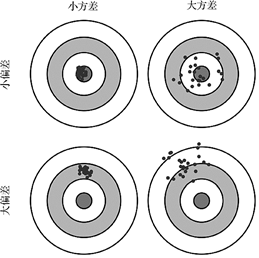
<div style="text-align: center;">图6-1  射击结果

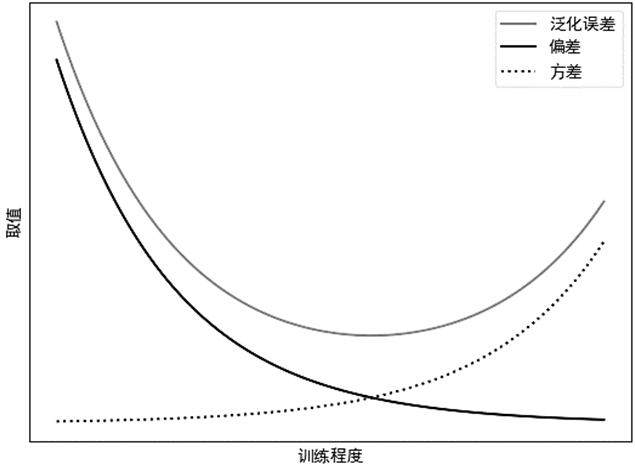
<div style="text-align: center;">图6-2  泛化误差与偏差、方差的关系

**4．偏差、方差与过拟合和欠拟合的关系**

一般来说，简单的模型会有一个较大的偏差和较小的方差，而复杂的模型会有较小的偏差和较大的方差。

<font color='red'>欠拟合</font>是指模型不能适配训练样本，可能具有一个较大的偏差。例如，如果在采样于多项式连续非线性数据的训练集上拟合一个线性模型，那么向模型提供多少数据不重要，因为线性模型根本无法表示数据的非线性关系，模型不能适配训练样本，有很大的偏差，此时需要更复杂的模型。那么，是不是模型越复杂、拟合程度越高越好呢？也不是，因为还有方差。

<font color='red'>过拟合</font>是指模型能较好地适配训练样本，但在测试集上表现很糟，具有很大的方差。方差就是指模型过拟合训练数据，以至于无法泛化或泛化能力较差。泛化正是机器学习要解决的问题，如果一个模型只能对一组特定的数据有效，换了数据就无效，则该模型过拟合。

**5．偏差、方差与模型复杂度的关系**

训练的学习模型必不可少地依赖数据。但是，如果我们不清楚数据服从什么分布，或者没办法拿到所有可能的数据（肯定拿不到所有数据），那么训练出来的模型和真实模型之间一定存在不一致性。这种不一致性表现为两方面：**偏差和方差**。既然偏差和方差是这么来的，而且它们是无法避免的，那么有什么方法可以尽量减小其对模型的影响呢？

一个好的方法就是正确选择<font color='red'>模型复杂度</font>。复杂度高的模型通常对训练数据有很好的拟合能力，但是对测试数据就不一定了。而复杂度太低的模型不能很好地拟合训练数据，更不能很好地拟合测试数据。因此，模型复杂度与模型的偏差和方差的关系如图 6-3 所示。

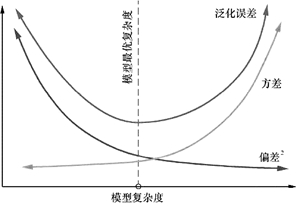
<div style="text-align: center;">图6-3  泛化误差、偏差、方差和模型复杂度

#### <font color='blue' >6.1.2.2  偏差与方差的进一步讨论</font>

现在知道了什么是模型的偏差与方差，还需要进一步理解**集成学习框架**中的<font color='red'>Boosting和Bagging方法与偏差、方差的关系</font>是什么，如何根据偏差与方差这两个指标来指导模型的改进和优化。

**集成学习框架中的基学习器**通常是<font color='red'>偏差大</font>（在训练集上的准确性低）、<font color='red'>方差小</font>（防止过拟合能力强）的弱模型。

我们经常用<font color='red'>过拟合</font>和<font color='red'>欠拟合</font>来定性描述模型是否能够较好地解决待定问题。从定量的角度来说，我们可以用模型的偏差与方差来描述模型的性能。集成学习往往能够“神奇”地提升弱学习器的性能。本节从偏差与方差的角度解释这背后的机理。

**1．偏差、方差与Bagging、Boosting的关系**

下面通过对Boosting和Bagging进行分析来简单回答这个问题：<font color='red'>Bagging能够提升弱分类器性能的原因是减小了方差，Boosting能够提升弱分类器性能的原因是减小了偏差</font>，为什么这么讲呢？

首先，<font color='red'>Bagging</font>是Bootstrap Aggregating的简称，意思就是<font color='red'>再抽样</font>，并对在每个样本子集上训练出来的模型的输出结果取平均值。

假设有 $n$ 个随机变量，方差记为 $\sigma^2$，两两变量之间的相关性为 $\rho$ ，则 $n$ 个随机变量的平均值 $\frac{\sum_i X_i}{n}$ 的方差为 $\rho{\sigma}^2+(1-\rho){\sigma}^2 /n$。在随机变量完全独立的情况下， $n$ 个随机变量的方差为 $\sigma^2/n$ ，即方差减小为原来的 $1/n$ 。

然后从模型的角度来理解**偏差、方差与bagging、boosting的关系**，对 $n$ 个独立不相关模型的预测结果取平均，其方差是原来单个模型的 $1/n$。这个描述不甚严谨，但原理已经讲得很清楚了。当然，模型之间不可能完全独立。为了追求模型的独立性，诸多Bagging方法做了不同的改进。例如，在随机森林算法中，每次选取节点分裂属性时，会随机抽取一个属性子集，而不是从所有属性中选取最优属性，这是为了避免弱分类器之间过强的相关性。通过训练集的重采样也能够带来弱分类器之间一定的独立性，从而减小Bagging后模型的方差。

最后看**Boosting**，在训练好一个弱分类器后，需要计算弱分类器的<font color='red'>分类错误</font>或<font color='red'>残差</font>，作为下一个分类器的<font color='red'>输入</font>。这个过程本身就是在不断地减小损失函数，使模型不断逼近“靶心”，使得模型偏差不断减小。但Boosting的过程并不会显著减小方差。这是因为Boosting的训练过程使得各弱分类器之间是强相关的，缺乏独立性。

从图 6-3 中不难看出，方差和偏差是相辅相成，矛盾又统一的，二者并不能完全独立的存在。对于给定的学习任务和训练数据集，需要对模型复杂度做合理的假设。

如果模型复杂度过低，则虽然方差很小，但是偏差会很大；如果模型复杂度过高，则虽然偏差减小了，但是方差会很大。因此，需要综合考虑偏差和方差选择合适的复杂度进行训练。

下面用用一个简单的等式来演示Bagging是如何减小方差的。假设测量一个随机变量 $x$ ，它服从正态分布，表示为 $N\left(\mu{\sigma}^2\right)$ ，其中， $\mu$ 是平均值，它也可以表示中位数； $\sigma$ 是标准差。

假设测量随机变量 $x{\,} P$ 次，记为 $\left(x_1,x_2,\ldots,x_p\right)$。很明显，$\left(x_1,x_2,\ldots,x_p\right)/P$ 的平均值保持不变，仍是 $\mu$；但是其方差会是原来的 $\frac1 P$，即

<div style="text-align: center;">$\frac {Var(x_1)+Var(x_2)+\ldots+Var(x_P)}{P^2} = \frac{P\sigma^2}{P^2} =\frac{\sigma^2}{P}$

Bagging在决策树等大方差模型上表现良好；在线性回归等小方差模型上，预计不会影响学习过程。在具有大偏差的模型上进行Bagging时，其准确性可能会降低。在比较Bagging和No-Bagging模型的性能时，这一点很明显。在No-Bagging下，大偏差模型的精度可能比对其实施Bagging时更高。

**2．偏差、方差和$K$折交叉验证的关系**

由前面已知，**$K$** **折交叉验证的方法**将原始数据集均分为 $K$ 个子集，每个子集分别作为验证集，其余 $K-1$ 个子集作为训练集，这样会得到 $K$ 个模型，这 $K$ 个模型在验证集上的回归误差的平均值或分类准确率的平均值作为此 $K$ 折交叉验证下回归器或分类器的性能指标。

关于一系列模型 $F\left(\widehat{f},\theta\right)$，使用交叉验证的目的是获得预测误差的无偏估计量CV，从而可以用来选择一组最优参数 $\theta$ ，使得CV最小。假设 $K$ 折交叉验证，CV统计量定义为每个子集中误差的平均值：

<div style="text-align: center;">$CV=\frac{1}{K} \sum_{k=1}^K\frac {1}{m}\sum_{i=1}^m\left(\widehat f^{k}-y_i\right)^2 $

>其中， $m=N/K$ 是每个子集中数据样本的大小； $N$ 是总训练样本量； $K$ 是子集数量。

$K$ 的大小与CV的偏差和方差是有关的，当 $K$ 较大时， $m$ 较小，在具有 $N-m$ 个样本的训练集上拟合模型，经过多次平均可以学习到更符合真实数据分布的模型，偏差较小，模型更加拟合训练集，测试集上测误差的期望值变大，从而方差较大；$K$ 较小时，模型不会过拟合训练数据，偏大，方差较小。

**3．如何解决偏差和方差问题**

由上述可知，偏差和方差是无法完全避免的，只能尽量减小它们的影响。

- 为了避免偏差，尽量选择适配的模型。例如，使用线性模型解决一个非线性问题，大偏差是无法避免的。<font color='red'>选择复杂度合适的模型</font>，<font color='red'>复杂度高的模型通常对训练数据有很好的拟合能力</font>。

- <font color='red'>慎重选择数据集的大小</font>。<font color='red'>通常数据集越大越好，使用更多的数据可以减小数据扰动造成的影响</font>。当规模较大的数据集对整体数据有一定的代表性后，增加样本数据也不能提升模型性能，反而会增加计算量。而<font color='red'>数据集太小一定是不好的，这会带来过拟合</font>，模型复杂度太高，方差很大，不同的数据集训练出来的模型的变化也较大。

为了**避免欠拟合**，**减小偏差**，可采用方法有：

- 寻找<font color='red'>更具代表性的特征</font>；

- 使用<font color='red'>更多的特征</font>，<font color='red'>增加输入向量维度</font>，选择模型要相应地<font color='red'>提升复杂度</font>。

为了**避免过拟合，减小方差**，可采用方法有：

- <font color='red'>增加</font>训练集中的<font color='red'>样本数据</font>；

- <font color='red'>减少数据特征</font>，<font color='red'>降低数据维度和模型复杂度</font>；

- 尽可能采用<font color='red'>正则化方法</font>；

- 尽可能采用<font color='red'>交叉验证法</font>。

## <font color='blue' >Bagging元估计器</font>

在集成算法中，**Bagging方法**首先在原始训练集的若干随机子集上分别构建相应基估计器实例，然后聚合基估计器的单独预测以形成最终预测。该方法被用作减小基估计器（如决策树）方差的一种方法。在许多情况下，Bagging方法是一种非常简单的集成策略，在采用不同的基模型时，无须调整底层的基本算法。

Bagging方法具有很多不同的分支或版本，主要是它们的随机抽取训练子集的方式不同。

- 当<font color='red'>数据集的随机子集被抽取为样本的随机子集</font>时，该算法被称为**粘贴**（Pasting）。

- 当<font color='red'>抽取替换样本</font>时，该方法称为**Bagging**。这也是本书主要讨论的一种方法。

- 当<font color='red'>数据集的随机子集被抽取为特征的随机子集</font>时，该方法被称为**随机子空间**（Random Subspaces）。

- 当<font color='red'>基估计器建立在样本和特征的子集上</font>时，该方法被称为**随机补丁**（Random Patches）。

**Bagging**是Bootstrap Aggregating的简写，意为**自助抽样集成**，是并行集成式学习的代表，如图 6-4 所示。第一个问题是何时使用Bagging？<font color='red'>只有当模型过于复杂，仅决策树易产生过拟合时，才使用Bagging</font>。从样本集中有放回抽样若干样本子集，针对每个样本子集分别训练一个基学习器。融合多个基学习器结果并产生最终预测。在输出预测时，如果是分类任务，则执行简单投票操作；如果是回归任务，则执行简单地求平均值操作；也可以进一步考虑投票的置信度，得出预测结果。

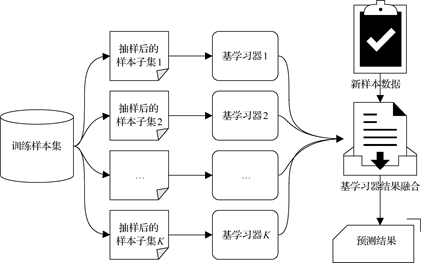
<div style="text-align: center;">图6-4  Bagging框架

自原始数据集 $D$ 中随机抽样一个样本 $x_i$，记下并放回，重复 $N$ 次，得到一个由 $N$ 个样本组成的样本子集，其中的样本可重复；这是一个样本子集的抽取。<font color='red'>Bagging策略步骤</font>如下：

- 在原始数据集 $D$ 上有放回的抽取 $K$ 个样本容量为 $N$ 样本子集，在每个样本子集上训练一个<font color='red'>基学习器</font>；

- $K$ 个没有依赖关系的基学习器融合，依据问题类型，执行投票/求均值操作。

如此，有些样本可能会被抽样多次，而有的样本一次也抽不到。假设有 $N$ 个样本，每个样本被抽中的概率都是 $\frac1 N$，没被选中的概率就是 $1- \frac1 N$，重复 $N$ 次都没被选中的概率就是 $\left(1-\frac{1}{N}\right)^N$，当 $N$ 趋于无穷大时，这个概率就是 $\frac1 e$ ，大概为36.8%。也就是说样本足够多的时候，一个样本没被选上的概率有36.8%，这些没被选中的数据可以留作验证集。每一次自助抽样生成训练样本集时，其验证集都是不同的。以这些<font color='red'>没被选中的样本作为验证集的方法</font>称为**包外估计**。


<font color='red'>在不同的样本子集上训练基学习器时，Bagging通过减小误差的方差来减小误差</font>。换句话说，由于Bagging策略中各样本子集是不同的，因此在投票环节，它们的误差相互抵消，能降低过拟合。另外，一些样本中的异常值可能直接被忽略。

在Scikit-learn中，**Bagging方法**是作为一个统一的BaggingClassifier（或BaggingRegressor）元估计器被提供的，将基估计器及抽取随机子集策略参数作为输入。在BaggingClassifier和BaggingRegressor中，**参数max_samples和max_features**<font color='red'>控制子集的大小</font>（根据样本和特征）。

**参数max_samples**是用于训练每个基估计器从X中抽取的<font color='red'>样本数量</font>（在默认情况下，样本抽取是可替换的），如果是int值，则为抽取的样本数量；如果是float值，则为抽取max_samples*X.shape[0]个样本。

**参数max_features**是从X中抽取训练每个基估计器的<font color='red'>特征数量</font>（在默认情况下，特征抽取是不可替换的）。如果其类型为int，则抽取max_features个特征；如果其类型为float，则提取max(,int(max_features*n_features_in_))个特征。

**参数bootstrap和bootstrap_features**用于<font color='red'>控制抽取的样本与特征是否用于替换</font>。Bootstrap的默认值为True，bootstrap_features的默认值为False。当使用可用样本的子集时，还可通过设置oob_score = True来估计包外样本的泛化精度。例如，下面的代码片段说明了如何实例化KNeighborsClassifier作为基估计器的Bagging集成，每个估计器都建立在50%样本和50%特征的随机子集上。

In [36]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
bagging = BaggingClassifier(KNeighborsClassifier(), max_samples=0.5, max_features=0.5)


**例6-1：单估计器和Bagging方法：偏差-方差分解。**

>本例展示并比较**单估计器**和**Bagging方法**的<font color='red'>均方误差期望的偏差-方差分解</font>。在下面的描述中，学习样本被标注为“LS”。  
>图 6-5展示的是本例运行结果：   
1.**左上子图**显示了在一个一维回归问题的随机数据集LS上训练的单棵决策树的预测（深红色点）。它还展示了在问题的其他（和不同）随机抽取的实例LS上训练的其他单棵决策树的预测（浅红色点）。为了更直观地展示方差项，将其对应于各个估计器的预测值束的宽度（浅红色）。方差越大，对x的预测相对于训练集中的小变化就越敏感。偏差项对应于估计器的平均预测（青色）和最优可能模型（深蓝色）之间的差。在这个问题上，可以观察到偏差非常小（青色和蓝色曲线都很接近），而方差很大（红色线束相当宽）。   
2.**左下子图**绘制了单棵决策树的均方误差期望的逐点分解。它证实了<font color='red'>偏差</font>（蓝色）较小，而<font color='red'>方差</font>较大（绿色）。它还说明了误差的噪声部分，正如预期的那样，噪声看起来是恒定的，大约为0.01。   
3.**右上、下子图**是使用了决策树的Bagging方法。在这两个子图中可以观察到，偏差项比前面的情况更大。在右上子图中，平均预测（青色）和最优可能模型之间的差异较大（例如，请注意x=2附近的偏移）。在右下图中，偏差曲线也略高于左下子图的偏差曲线。然而，就方差而言，预测值束较窄，这表明方差较小。事实上，正如右下图所证实的，Bagging决策树的方差项（绿色）小于单棵决策树的方差项。总的来说，偏差-方差分解因此不再相同。一个折衷的方案更适合Bagging方法：对数据集的Bootstrap副本上的几棵决策树进行平均会略微增大偏差项，但可能会有较大幅度的方差减少，这会导致较小的总体均方误差。Bagging方法的总误差小于单棵决策树的总误差，这种差异实际上主要来源于方差的减小。   

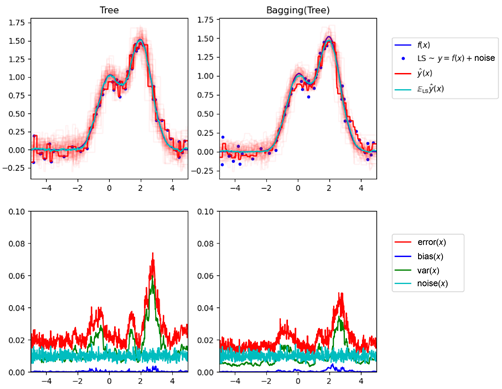
<div style="text-align: center;">图6-5  单估计器和Bagging方法：偏差-方差分解

Tree: 0.0255 (error) = 0.0003 (bias^2) + 0.0152 (var) + 0.0098 (noise)


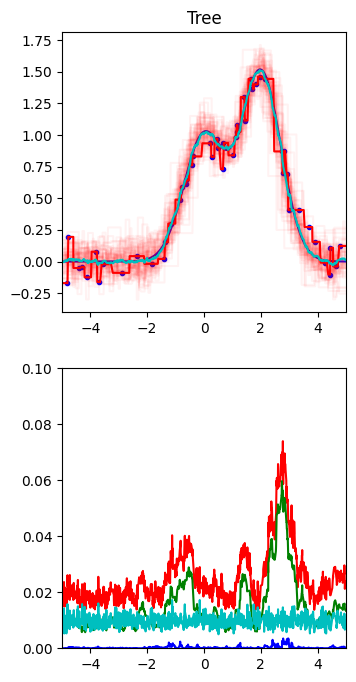

Bagging(Tree): 0.0196 (error) = 0.0004 (bias^2) + 0.0092 (var) + 0.0098 (noise)


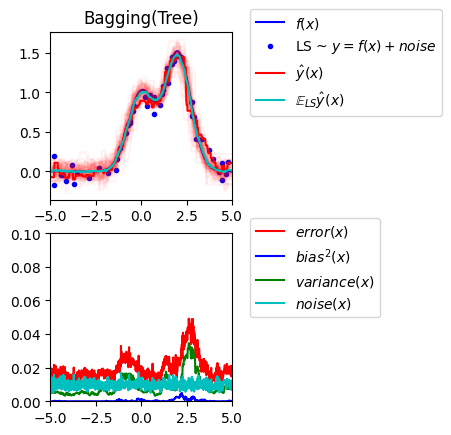

In [25]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

n_repeat = 50   # 计算期望的迭代次数
n_train = 50   # 训练集的大小
n_test = 1000   # 测试集的大小
noise = 0.1   # 噪声标准差
np.random.seed(0)

# 更改此项以探索其他估计器的偏差-方差分解。这应该适用于具有高方差的估计器（如决策树或KNN），但对于具有低方差的估计器（如线性模型）效果不佳
estimators = [("Tree", DecisionTreeRegressor()), ("Bagging(Tree)", BaggingRegressor (DecisionTreeRegressor())),]
n_estimators = len(estimators)  # 估计器数量 


def f(x):  
    x = x.ravel()
    return np.exp(-(x**2)) + 1.5 * np.exp(-((x - 2) ** 2))


def generate(n_samples, noise, n_repeat=1): # 生成数据
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X)

    if n_repeat == 1:
        y = f(X) + np.random.normal(0.0, noise, n_samples)
    else:
        y = np.zeros((n_samples, n_repeat))
        for i in range(n_repeat):
            y[:, i] = f(X) + np.random.normal(0.0, noise, n_samples)

    X = X.reshape((n_samples, 1))
    return X, y


X_train = []
y_train = []

for i in range(n_repeat):
    X, y = generate(n_samples=n_train, noise=noise)
    X_train.append(X)
    y_train.append(y)

X_test, y_test = generate(n_samples=n_test, noise=noise, n_repeat=n_repeat)

plt.figure(figsize=(10, 8))
# 在估计器上循环以进行比较
for n, (name, estimator) in enumerate(estimators): 
    y_predict = np.zeros((n_test, n_repeat))   

    for i in range(n_repeat):
        estimator.fit(X_train[i], y_train[i])
        y_predict[:, i] = estimator.predict(X_test) # 计算预测

    # 均方误差的分解：bias^2 + Var + noise
    y_error = np.zeros(n_test)

    for i in range(n_repeat):
        for j in range(n_repeat):
            y_error += (y_test[:, j] - y_predict[:, i]) ** 2

    y_error /= n_repeat * n_repeat

    y_noise = np.var(y_test, axis=1)
    y_bias = (f(X_test) - np.mean(y_predict, axis=1)) ** 2
    y_var = np.var(y_predict, axis=1)

    print("{0}: {1:.4f} (error) = {2:.4f} (bias^2) + {3:.4f} (var) + {4:.4f} (noise)".format(
            name, np.mean(y_error), np.mean(y_bias), np.mean(y_var), np.mean(y_noise)
        )
    )

    plt.subplot(2, n_estimators, n + 1)  # 绘制图
    plt.plot(X_test, f(X_test), "b", label="$f(x)$")
    plt.plot(X_train[0], y_train[0], ".b", label="LS ~ $y = f(x)+noise$")

    for i in range(n_repeat):
        if i == 0:
            plt.plot(X_test, y_predict[:, i], "r", label=r"$\^y(x)$")
        else:
            plt.plot(X_test, y_predict[:, i], "r", alpha=0.05)

    plt.plot(X_test, np.mean(y_predict, axis=1), "c", label=r"$\mathbb{E}_{LS} \^y(x)$")

    plt.xlim([-5, 5])
    plt.title(name)

    if n == n_estimators - 1:
        plt.legend(loc=(1.1, 0.5))

    plt.subplot(2, n_estimators, n_estimators + n + 1)
    plt.plot(X_test, y_error, "r", label="$error(x)$")
    plt.plot(X_test, y_bias, "b", label="$bias^2(x)$"),
    plt.plot(X_test, y_var, "g", label="$variance(x)$"),
    plt.plot(X_test, y_noise, "c", label="$noise(x)$")

    plt.xlim([-5, 5])
    plt.ylim([0, 0.1])
	
    if n == n_estimators - 1:
	    plt.legend(loc=(1.1, 0.5))
	
    plt.subplots_adjust(right=0.75)
    plt.show()


**结果解析：**

>**单估计器：**  
1.预测曲线（红色）波动剧烈 → 高方差；  
2.误差图中绿色方差部分较宽。  
因此，单估计器存在低偏差但高方差（有过拟合的风险）的问题。

>**Bagging方法：**
预测曲线更平滑 → 方差减小；  
误差图中绿色部分明显变窄。  

>**bagging法的作用**：通过 bootstrap 采样和平均预测，虽然小幅增加偏差，但有效降低方差。  

该代码完整展示了如何通过偏差-方差分解诊断模型问题，并验证了集成学习方法对降低方差的有效性。  

## <font color='blue' >6.3 随机森林</font>
<p style="line-height: 1.5;">

**随机森林**是Bagging的一个扩展变体，如图6-6所示。<font color='red'>随机森林以决策树为基学习器，构建Bagging结构</font>，在训练过程中引入随机因素。例如，在前第5章的决策树的构建过程中，在某节点处选择特征划分样本是在当前所有特征中选择最优特征。而随机森林是先从特征集中随机选出若干特征子集，然后从该子集中选出最优特征作为决策树当前节点的划分特征。如果随机选择的特征子集数量为1，则在所有特征中选择最优特征，随机森林和传统决策树相同。一般推荐特征子集数量为$\rm log_2$ (n_features)或sqrt (n_features)，其中n_features是特征数量。

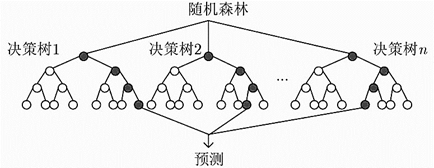 
<div style="text-align: center;">图6-6  随机森林

当采用Bootstrap策略生成 $K$ 个样本子集时，每个样本子集的样本数量不一定要等于原始样本集的样本数量。例如：可以生成一个含有0.75$N$ 个样本的样本子集，此时的0.75就称为<font color='red'>采样率</font>。

当使用样本集中的0.75$N$ 个样本生成决策树时，假设采用ID3算法，生成节点时以<font color='red'>信息增益</font>作为判断依据。具体做法是把每个特征都拿来试一试，最终信息增益最大的那个特征就是要选的特征。在选择划分特征时，仅从随机选取的特征子集中进行选择，如从20个特征中的16个中选择划分特征。由此，当前最优划分特征出现在那4个没选取的特征中是有可能的，但在下一次分裂节点的过程中，该特征有可能列入16个待选取特征中。另外，一棵决策树中可能出现在另一颗决策树中没有使用过的特征。

由此，在利用Bagging策略生成一个决策树集合的过程中，同时满足<font color='red'>样本随机</font>和<font color='red'>特征随机</font>，构建好的多棵决策树组成了一片“森林”，称为**随机森林**。当然，也可以使用<font color='red'>SVM、逻辑回归</font>等作为Bagging策略中的基学习器，习惯上依旧称为随机森林。

随机森林简单易实现，计算开销比较小。随机森林的训练不仅来自样本扰动，还来自特征扰动，集成后其泛化效果较好。随机森林的收敛性与Bagging相似，随机森林的起始性能相对较差，尤其在仅含有一个基学习器时，随着学习器数量的增加，随机森林通常会收敛到更小的泛化误差。通过组合多个弱分类器，整体模型具有较高的精确率和泛化性能。

### <font color='blue' >6.3.1  随机森林算法</font>

sklearn.ensemble模块包括两种基于随机决策树的平均算法：**随机森林**和**极度随机化树**。这两种算法都是专门为树设计的扰动和组合技术，通过在基学习器构造中引入随机性创建一组不同的基学习器。集成方法的预测为各基学习器的预测的平均值，集成中的每棵树都是由训练集中的替换单样本子集构建的。

与其他分类器一样，首先导入RandomForestClassifier包，由类构造函数RandomForestClassifier　(n_estimators=10)生成含有10个基学习器的<font color='red'>集成分类器clf</font>。随机森林分类器必须拟合两个数组：<font color='red'>保存训练样本的形状</font>为(n_samples,n_features)的稀疏或密集<font color='red'>数组X</font>，以及<font color='red'>保持训练样本目标值</font>（类标签）的形状为(n_samples,)的<font color='red'>数组Y</font>。

In [37]:
from sklearn.ensemble import RandomForestClassifier  
X = [[0, 0], [1, 1]]  
Y = [0, 1]  
clf = RandomForestClassifier(n_estimators=10)  
clf = clf.fit(X, Y)  

与决策树一样，如果Y是形状为(n_samples, n_outputs)的数组，则随机森林集成方法扩展到多输出问题。

<font color='red'>样本和特征的随机性的目的是减小森林估计器的方差</font>。事实上，单棵决策树通常表现出大方差，并倾向于过拟合。森林中注入的随机性产生的决策树具有一定程度地解耦预测误差。通过取这些预测的平均值，一些误差可以抵消。<font color='red'>随机森林通过组合不同的决策树来减小方差，有时会以略微增大偏差为代价</font>。在实践中，方差的减小通常是显著的，因此产生了一个总体上更好的模型。

### <font color='blue' >6.3.2  极度随机化树</font>

为了引入极度随机化树，Scikit-learn包含了**ExtraTreesClassifier**和**ExtraTreesRegressor**类。<font color='red'>在计算节点拆分的方式中采取进一步的随机性</font>。例如，随机森林使用了候选特征的随机子集，但极度随机化树并没有寻找最具鉴别性的阈值，而是为每个候选特征随机抽取阈值，并在这些随机生成的阈值中选择最好的阈值作为分割规则。这通常会导致更大地减小模型的方差，但代价是偏差的增加略大。

In [27]:
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier

X, y = make_blobs(n_samples=10000, n_features=10, centers=100, random_state=0)
clf = DecisionTreeClassifier(max_depth=None, min_samples_split=2, random_state=0)
scores = cross_val_score(clf, X, y, cv=5)
scores.mean()


np.float64(0.9823000000000001)

In [28]:
clf = RandomForestClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=0)
scores = cross_val_score(clf, X, y, cv=5)
scores.mean()

np.float64(0.9997)

In [29]:
clf = ExtraTreesClassifier(n_estimators=10, max_depth=None, min_samples_split=2, random_state=0)
scores = cross_val_score(clf, X, y, cv=5)
scores.mean() > 0.999

np.True_

当使用**随机森林方法**时，要调整的主要**参数**有**n_estimators**和**max_features**。<font color='red'>前者是森林中树的数量，其值越大越好，但计算所需的时间也越长</font>。此外，请注意，当森林中的决策树数量超过临界数量时，结果将不再显著好转。后者是在分割节点时要考虑的随机子集的特征的数量。对于回归问题，一个好的经验默认值为max_features=1.0或等效的max_features=None，即考虑所有特征而不是随机子集；对于分类任务，一个好的经验默认值为max_features="sqrt"，即使用特征数量为sqrt(n_feature)的随机子集，其中n_features是数据集中特征的数量。<font color='red'>max_features取默认值1时相当于Bagged树，并且可以通过设置较小的值来实现更高的随机性</font>（如max_featrues=0.3是文献中的典型默认值）。当组合设置max_depth=None与min_samples_split=2时，即当完全开发树时，通常会获得良好的结果。请记住，这些值通常不是最优值，并且可能导致模型消耗大量内存。最优参数值应是交叉验证的结果。此外，请注意，在随机森林中，默认情况下设置bootstrap=True，而极度随机化树的默认策略是使用整个数据集，即设置bootstrap=False。

采有<font color='red'>默认参数的模型大小为 $O(MN\log(N))$</font>，其中， $M$ 是<font color='red'>树的数量</font>， $N$ 是<font color='red'>样本数量</font>。为了减小模型的大小，可以更改以下**参数**：**min_samples_split**、**max_leaf_nodes**、**max_depth**和**min_samples_leaf**。

sklearn.ensemble模块中的随机森林相关函数还可通过**n_jobs参数**实现<font color='red'>树的并行构建和预测的并行计算</font>。如果设置**n_jobs=k**，则<font color='red'>计算被划分为k个作业，并在机器的k个核心上运行</font>。如果**n_jobs=-1**，则<font color='red'>使用机器上可用的所有核心</font>。请注意，由于进程间通信的开销，加速可能不是线性的，即使用k个作业的速度不是原速度的k倍。在大型数据集上构建大量树时，或者在构建单棵树时需要相当长的时间，但仍然可以实现显著加速。

### <font color='blue' >6.3.4  随机森林实践</font>

**例6-2：在iris数据集上绘制树集成的决策面。**

>本例的目的是通过可视化对比四种分类器在<font color='red'>iris数据集</font>不同特征组合上学习的决策面，展示了不同集成学习方法的表现差异。    

>**数据集**：使用 sklearn.datasets.load_iris() 加载iris数据集（3类，4个特征）。   

>**对比模型**：  
>-  决策树分类器（第一列）  
>-  随机森林分类器（第二列）  
>-  极度随机化树分类器（第三列）  
>-  AdaBoost分类器（第四列）  

>**特征组合**：对不同的特征组合 [0,1], [0,2], [2,3] 分别训练模型，观察分类效果。  

>**可视化**：绘制决策面和数据点分布，直观比较不同模型的分类能力。

>在第一行中，分类器仅使用萼片宽度（sepal width）和萼片长度（sepal length）特征来构建；  
>在第二行中，仅使用花瓣长度（petal length）和萼片长度来构建；  
>在第三行中，仅使用花瓣宽度（petal width）和花瓣长度来构建。  

按照得分降序排序，当使用30个估计器对所有4个特征进行训练（在本例之外）并使用10折交叉验证进行评分时，可以看到：

In [45]:
from sklearn.ensemble import AdaBoostClassifier
ExtraTreesClassifier()  # 0.95 score  
RandomForestClassifier()  # 0.94 score  
AdaBoostClassifier(DecisionTreeClassifier(max_depth=3))  # 0.94 score  
DecisionTreeClassifier(max_depth=None)  # 0.94 score

DecisionTreeClassifier()

加AdaBoost的max_depth会减小得分的标准差（但平均得分并不会改进）。有关每个模型的更多详细信息，请参阅下面的控制台的输出。

在**例 6-2** 中，还进行了如下尝试：

>改变**DecisionTreeClassifier**和**AdaBoostClassifier**的<font color='red'>max_depth</font>，也尝试设置**DecisionTreeClassifier**的<font color='red'>max_depth=3</font>或**AdaBoost分类器**的<font color='red'>max_depth=None</font>。

>改变**n_estimators**。

值得注意的是，**随机森林**和**极度随机化树**可以在多核计算机上<font color='red'>并行拟合</font>，因为每棵树都是独立于其他树构建的。**AdaBoost**的所用样本是按顺序构建的，因此<font color='red'>不能使用多个内核<font>。

>**算法步骤**
>1. **数据准备**  
加载 iris 数据集（X：4个特征，y：3类标签）。  
选择 两两特征组合（如 [0,1] 表示 sepal_length 和 sepal_width）。  
数据标准化（(X - mean) / std），使不同特征尺度一致。  
>2. **模型训练**  
对每个特征组合 pair 和每个模型 model：  
数据划分：仅使用选定的两个特征 X[:, pair]。  
数据打乱：np.random.shuffle 避免顺序偏差。  
训练模型：  
DecisionTreeClassifier（决策树）  
RandomForestClassifier（随机森林，n_estimators=30）  
ExtraTreesClassifier（极端随机树，n_estimators=30）  
AdaBoostClassifier（AdaBoost，基学习器为 max_depth=3 的决策树）  
>3. **决策边界可视化**  
精细网格（plot_step=0.02）：  
生成网格点 np.meshgrid，预测每个点的类别。  
使用 plt.contourf 绘制决策边界（颜色填充）。  
粗糙网格（plot_step_coarser=0.5）：  
用 plt.scatter 绘制稀疏预测点，展示分类器的全局趋势。  
数据点：用散点图显示原始数据（红色、黄色、蓝色分别对应 3 类）。  
>4. **结果输出**  
打印每个模型在特征组合上的 分类准确率（model.score(X, y)）。  
生成 3×4 的子图矩阵（3 个特征组合 × 4 个模型）。  

DecisionTree with features [0, 1] has a score of 0.9266666666666666
RandomForest with 30 estimators with features [0, 1] has a score of 0.9266666666666666
ExtraTrees with 30 estimators with features [0, 1] has a score of 0.9266666666666666
AdaBoost with 30 estimators with features [0, 1] has a score of 0.82
DecisionTree with features [0, 2] has a score of 0.9933333333333333
RandomForest with 30 estimators with features [0, 2] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [0, 2] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [0, 2] has a score of 0.9933333333333333
DecisionTree with features [2, 3] has a score of 0.9933333333333333
RandomForest with 30 estimators with features [2, 3] has a score of 0.9933333333333333
ExtraTrees with 30 estimators with features [2, 3] has a score of 0.9933333333333333
AdaBoost with 30 estimators with features [2, 3] has a score of 0.9866666666666667


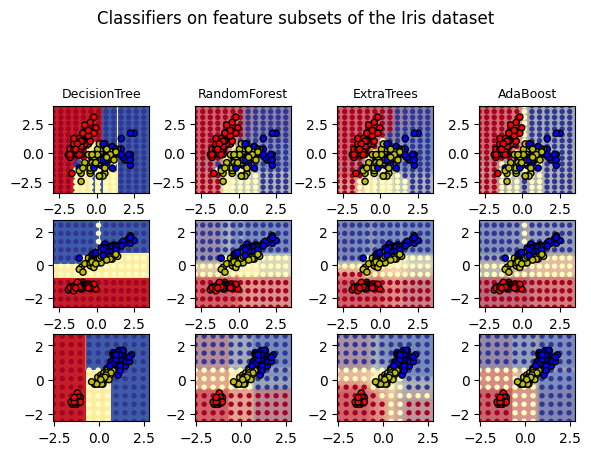

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_iris
from sklearn.ensemble import (AdaBoostClassifier, ExtraTreesClassifier, RandomForestClassifier,)
from sklearn.tree import DecisionTreeClassifier

# 参数
n_classes = 3
n_estimators = 30
cmap = plt.cm.RdYlBu
plot_step = 0.02  # 用于确定曲面轮廓的精细步长
plot_step_coarser = 0.5  # 用于粗分类器猜测的步长
RANDOM_SEED = 13  # 在每次迭代中固定种子

iris = load_iris()  # 加载数据集
plot_idx = 1

models = [
    DecisionTreeClassifier(max_depth=None),
    RandomForestClassifier(n_estimators=n_estimators),
    ExtraTreesClassifier(n_estimators=n_estimators),
    AdaBoostClassifier(DecisionTreeClassifier(max_depth=3), n_estimators=n_estimators),]

for pair in ([0, 1], [0, 2], [2, 3]):
    for model in models:
        X = iris.data[:, pair] # 仅取2个对应的特征
        y = iris.target

        idx = np.arange(X.shape[0])
        np.random.seed(RANDOM_SEED)
        np.random.shuffle(idx) # 重洗牌
        X = X[idx]
        y = y[idx]

        # 标准化
        mean = X.mean(axis=0)
        std = X.std(axis=0)
        X = (X - mean) / std
        
        model.fit(X, y)  # 训练

        scores = model.score(X, y)
        model_title = str(type(model)).split(".")[-1][:-2][: -len("Classifier")]

        model_details = model_title
        if hasattr(model, "estimators_"):
            model_details += " with {} estimators".format(len(model.estimators_))
        print(model_details + " with features", pair, "has a score of", scores)

        plt.subplot(3, 4, plot_idx)
        if plot_idx <= len(models):
            plt.title(model_title, fontsize=9) # 每列顶部添加标题

        # 现在使用精细网格作为填充轮廓图的输入来绘制决策边界
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))

        #绘制单个DecisionTree分类器或alpha混合分类器集合的决策面
        if isinstance(model, DecisionTreeClassifier):
            Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape)
            cs = plt.contourf(xx, yy, Z, cmap=cmap)
        else:
             #根据正使用的估计器的数量选择alpha混合级别
  #注意，如果AdaBoost在早期达到足够好的拟合，它可以使用比其最大值更少的估计器
            estimator_alpha = 1.0 / len(model.estimators_)
            for tree in model.estimators_:
                Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
                Z = Z.reshape(xx.shape)
                cs = plt.contourf(xx, yy, Z, alpha=estimator_alpha, cmap=cmap)

         # 构建一个更粗糙的网格来绘制一组集成分类，
  # 以显示这些分类与我们在决策曲面中看到的分类有何不同。
  # 这些点是规则的空间，且没有黑色轮廓
        xx_coarser, yy_coarser = np.meshgrid(
            np.arange(x_min, x_max, plot_step_coarser),
            np.arange(y_min, y_max, plot_step_coarser),
        )
        Z_points_coarser = model.predict(np.c_[xx_coarser.ravel(), yy_coarser.ravel()]). reshape(xx_coarser.shape)
        cs_points = plt.scatter(xx_coarser, yy_coarser, s=15, c=Z_points_coarser, cmap=cmap, edgecolors="none",)

        #绘制训练点，这些训练点聚集在一起，并具有黑色轮廓
        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=ListedColormap(["r", "y", "b"]), edgecolor="k", s=20,)
        plot_idx += 1  #按顺序进行下一个绘图

plt.suptitle("Classifiers on feature subsets of the Iris dataset", fontsize=12)
plt.axis("tight")
plt.tight_layout(h_pad=0.2, w_pad=0.2, pad=2.5)
plt.show()

#输出结果如下：

<div style="text-align: center;">图6-7  随机森林决策面比较

>**结果解析**  
>1. 分类准确率  
**决策树分类器**：  
  在简单特征组合（如 [0,1]）上可能表现一般（线性不可分）。  
  在更复杂的组合（如 [2,3]，花瓣尺寸）上表现较好。  
**随机森林分类器 & 极度随机化树分类器**：  
  由于集成多棵树的投票机制，准确率通常高于单棵决策树。  
  ExtraTrees 的随机性更强，可能在某些情况下略优于 RandomForest。
**AdaBoost分类器**：
  通过迭代调整样本权重，对难样本更敏感。
  若基学习器（max_depth=3 的决策树）较简单，可能欠拟合。
>2. 决策边界可视化  
**决策树**：  
  边界呈轴平行分割（矩形区域），可能过拟合。  
**随机森林 & 极端随机树**：
  边界更平滑（多棵树投票平均）。
  ExtraTrees 的边界可能更“破碎”（更强的随机性）。  
**AdaBoost**：
  边界可能呈现 局部细化（对错误分类区域重点优化）。  
>3. 关键观察  
**特征重要性**：  
组合 [2,3]（花瓣长度和宽度）通常分类效果最好，因为花瓣特征对iris类别区分度最高。  
**模型复杂度**：  
决策树容易过拟合（边界锯齿状），集成方法（如随机森林）泛化性更好。  
**AdaBoost 的基学习器影响**：  
如果基学习器太弱（如 max_depth=1），可能欠拟合；max_depth=3 是一个折中选择。  

### <font color='blue' >6.3.5  算法小结</font>

通过本节的学习，读者可以了解**随机森林**以**决策树**为基学习器，采用**Bagging集成策略**，并在其训练过程中引入**样本随机性**和**特征随机性**。随机森林除了简单易实现，计算开销较小、泛化效果较好等优点，还具有以下<font color='red'>特点</font>：

- 由于采用了集成算法，因此其精度一般优于多数单模型算法的精度；  
- 在测试集上表现良好，随机性的引入降低了过拟合风险；  
- 决策树的组合可以让随机森林处理非线性数据；  
- 训练过程中可以检测特征的重要性，是常见的特征筛选方法；  
- 每棵树可以同时生成，并行效率高，训练速度快；  
- 可以自动处理默认值。

## <font color='blue' >6.4　Boosting算法</font>

Boosting框架如图 6-8 所示，训练过程为阶梯状，多个**基学习器**（由于其分类/回归性能较弱，有时也称为弱学习器）依次训练；组合多个**弱学习器**形成一个**强学习器**，主要步骤如下：

- 设 $T=\left[(x_1,y_1)(x_2,y_2),\ldots,(x_n,y_n)\right]$ 是**原始训练集**，<font color='red'>初始化样本权重分布</font>，得到训练集 $T_1$。在这一步中，每个训练样本通常具有相同的权重。<font color='red'>通过加权训练集训练出第一个弱学习器模型</font>。
- <font color='red'>根据一定的规则更新样本的权重分布，得到新的训练集 $T_2$</font>。一般而言，如果第一个弱学习器对某一样本预测错误，则该样本在下一步的弱学习器训练过程中具有更大的权重。<font color='red'>通过训练集 $T_2$ 训练出第二个弱学习器模型</font>。
- <font color='red'>重复以上过程，得到若干</font>**弱学习器**，直到达到预定的学习器数量或预定的预测精度。
- <font color='red'>线性组合这些弱学习器</font>，得到一个**强学习器**。

在整个训练过程中，**Boosting**总是<font color='red'>更加关注被错误分类的样本</font>，<font color='red'>赋予其更大的关注度</font>（或权重），并通过训练下一个弱学习器来<font color='red'>减小分类误差</font>。

Boosting算法中常用的是<font color='red'>AdaBoost</font>、<font color='red'>Gradient Boosting</font>（代表算法<font color='red'>GBDT</font>）和<font color='red'>XGBoost</font>等。

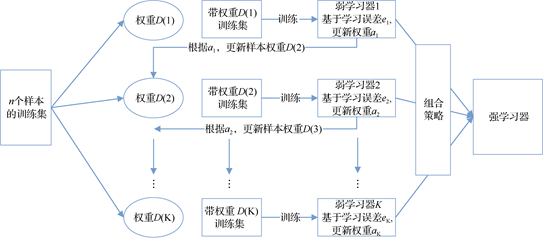
<div style="text-align: center;">图6-8  Boosting框架

## <font color='blue' >6.5　AdaBoost算法</font>

多数**Boosting方法**<font color='red'>改变训练样本的权重分布</font>，针对不同的权重分布训练一系列**弱分类器**。现在，还有两个问题需要解决。

**第一个问题**是<font color='red'>在每一轮次中，如何改变训练样本的权重或概率分布</font>。**AdaBoost**的做法<font color='red'>是增大那些被前一轮弱分类器错误分类样本的权重，并减小那些被正确分类的样本的权重</font>。在经过前一轮次的权重加大后，本轮次的弱分类器就会更关注那些没有被正确分类的样本。提供<font color='red'>迭代过程中的数据修正</font>功能，包括将权重 $w_1,w_2,\ldots,w_N$ 应用于每个训练样本。将这些权重初始化为 $w_i=1/N$ ，因此第一步只是在原始数据上训练弱学习器。<font color='red'>对于每个连续迭代，单独修改样本权重，并将学习算法重新应用于重新加权后的数据</font>。随着迭代的进行，难以预测的样本受到越来越大的关注。因此，每个后续的弱学习器都被迫专注于序列中前一个学习器遗漏的样本。依次类推，分类问题便会被一系列弱分类器“分而治之”。

**第二个问题**是如何<font color='red'>将弱分类器组合成一个强分类器</font>。**AdaBoost**采取的是<font color='red'>加权多数投票（或求和）</font>，将所有预测进行组合，以产生最终预测的方法。具体来讲，就是<font color='red'>加大错分率低的弱分类器的权重</font>，使其在表决中起更大的作用，并<font color='red'>减小错分率高的弱分类器的权重</font>，使其在表决中起较小的作用。

图6-9对AdaBoost 方法给出了一个直观的展示。

>Box1：假设所有样本具有相同的权重（正、负号的大小一致），分类器D1将它们分为两部分。浅色区域的3个正号样本被错误分类，这3个样本将被赋予更大的权重，由下一轮次的决策树进行分类。

>Box2：在Box1中3个未被正确分类的正号样本的权重变大（其尺寸变大）。第二轮次的分类器D2试图将这3个样本准确分类，但同时引入了新的分类错误，3个负号样本被错误分类，因此在下一轮次的分类中，这3个负号样本被赋予更大的权重。

>Box3：Box2中3个被错误分类的负号样本被赋予更大的权重，分类器D3进行新的分类，但此时又引入了新的分类错误，即用小圆圈圈起来的一个负号样本和两个正号样本。

>Box 4：将D1、D2和D3三个分类器组合起来形成一个复杂的规则，可以看出，该组合分类器比任何一个弱分类器的表现都好。

AdaBoost的细节详见进阶F。

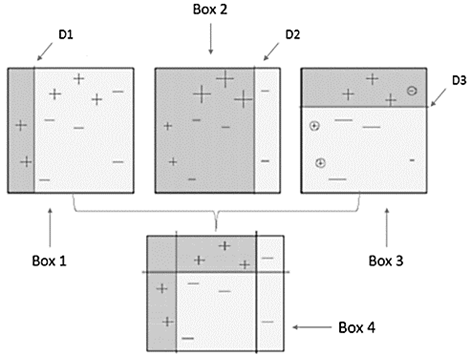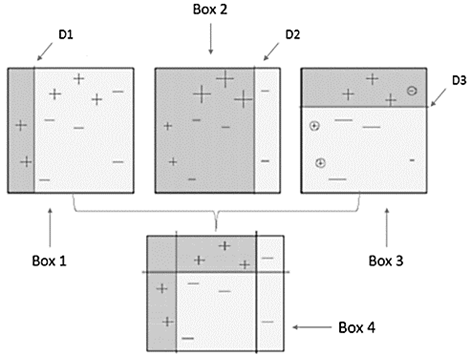
<div style="text-align: center;"> 图6-9  AdaBoost分类示例

### <font color='blue' >6.5.1  AdaBoost 实践</font>

**sklearn.ensemble模块**包括流行的Boost算法**AdaBoost**。AdaBoost可用于<font color='red'>分类和回归问题</font>。以下代码片段显示了如何拟合具有100个弱学习器的AdaBoost分类器。

In [41]:
from sklearn.model_selection import cross_val_score  
from sklearn.datasets import load_iris  
from sklearn.ensemble import AdaBoostClassifier  

X, y = load_iris(return_X_y=True)  
clf = AdaBoostClassifier(n_estimators=100)  
scores = cross_val_score(clf, X, y, cv=5)  
scores.mean()  

np.float64(0.9533333333333334)

由上可知，弱学习器数量由**参数n_estimators**来设置。除此之外，在**AdaBoostClassifier**和**AdaBoostRegressor**中，还有**learning_rate参数**，表示<font color='red'>梯度收敛速度</font>，默认为1，如果设置过大，则容易引起收敛振荡；如果过小，则收敛速度会很慢。通过调整**参数n_estimators**和**基估计器的复杂性**（如<font color='red'>深度</font>**max_depth**或<font color='red'>考虑分裂所需的最小样本数</font>**min_samples_split**）可获得良好的结果。可使用任何可接受加权数据集的机器学习算法作为基学习器，通过**参数base_estimator**进行设置。该原理同样用于回归算法。

In [44]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import numpy as np

# 模拟数据（假设 y 被错误生成为二维）
X = np.random.rand(100, 4)  # 100个样本，4个特征
y = np.random.randint(0, 2, (100, 1))  # 错误的 y 形状 (100, 1)

# 修正：展平 y
y = y.ravel()  # 现在形状是 (100,)

# 划分数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# 训练模型
dt = DecisionTreeClassifier(max_depth=1)
clf = AdaBoostClassifier(estimator=dt, n_estimators=100)
clf.fit(X_train, y_train)  # 不再报错

print("Accuracy:", clf.score(X_test, y_test))

Accuracy: 0.55


**例6-3：离散与实数AdaBoost。**（<font color='red'>注：本例由于参数“algorithm”在 sklearn 1.6 版本中已弃用且无效且它将在 1.8 版本中被移除,该例无法在高于1.6的sklearn版本之下运行。</font>）

本例展示了**离散SAMME提升算法**和**实数SAMME.R提升算法**之间的<font color='red'>性能差异</font>，如图 6-10 所示。这两种算法都在二分类任务上进行评估，其中目标Y是10个输入特征的非线性函数。

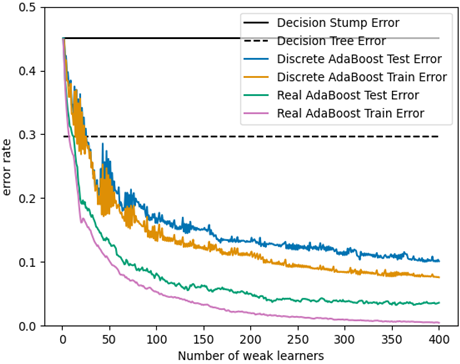
<div style="text-align: center;">图6-10  离散SAMME提升算法和实数SAMME.R提升算法间的性能差异

**离散SAMME提升算法**根据预测类别标签中的错误进行调整，而**实数SAMME.R**则使用预测类别的概率。

第一步，准备**数据和基线模型**。

>首先生成<font color='red'>二分类数据集</font>。

In [46]:
from sklearn import datasets  
X, y = datasets.make_hastie_10_2(n_samples=12_000,random_state=1)


>然后为AdaBoost分类器设置<font color='red'>超参数</font>。请注意，对于SAMME和SAMME.R算法，Scikit-learn 1.0的学习率可能不是最优的。

In [47]:
n_estimators = 400  
learning_rate = 1.0


>最后将数据集拆分为<font color='red'>训练集和测试集</font>，定义具有depth=9的<font color='red'>决策树分类器dt</font>和具有depth=1的<font color='red'>stump决策树分类器dt_stump</font>，训练基分类器并计算测试误差。

In [48]:
from sklearn.model_selection import train_test_split  
from sklearn.tree import DecisionTreeClassifier  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=2_000, shuffle=False)  
  
dt_stump = DecisionTreeClassifier(max_depth=1,min_samples_leaf=1)  
dt_stump.fit(X_train, y_train)  
dt_stump_err = 1.0 - dt_stump.score(X_test, y_test)  

dt = DecisionTreeClassifier(max_depth=9, min_samples_leaf=1)  
dt.fit(X_train, y_train)  
dt_err = 1.0 - dt.score(X_test, y_test)  


第二步，分别定义**离散SAMME**和**实数SAMME.R**的Adaboost分类器<font color='red'>ada_discrete</font>与<font color='red'>ada_real</font>，并拟合训练集。

In [ ]:
from sklearn.ensemble import AdaBoostClassifier  
  
ada_discrete = AdaBoostClassifier(  
    estimator=dt_stump,  
    learning_rate=learning_rate,  
    n_estimators=n_estimators,  
    algorithm="SAMME",)  
ada_discrete.fit(X_train, y_train)  

ada_real = AdaBoostClassifier(  
    estimator=dt_stump,  
    learning_rate=learning_rate,  
    n_estimators=n_estimators,  
    algorithm="SAMME.R",)  
ada_real.fit(X_train, y_train)  


通过<font color='red'>方法staged_predict(X_test)</font>计算**离散和实数AdaBoost分类器**在集成算法中的<font color='red'>n_estimators</font>个基分类器上的测试误差。

In [26]:
import numpy as np  
from sklearn.metrics import zero_one_loss  
  
ada_discrete_err = np.zeros((n_estimators,))  
for i, y_pred in enumerate(ada_discrete.staged_predict(X_test)):  
    ada_discrete_err[i] = zero_one_loss(y_pred, y_test)  
  
ada_discrete_err_train = np.zeros((n_estimators,))  
for i, y_pred in enumerate(ada_discrete.staged_predict(X_train)):  
    ada_discrete_err_train[i] = zero_one_loss(y_pred, y_train)  
  
ada_real_err = np.zeros((n_estimators,))  
for i, y_pred in enumerate(ada_real.staged_predict(X_test)):  
    ada_real_err[i] = zero_one_loss(y_pred, y_test)  
  
ada_real_err_train = np.zeros((n_estimators,))  
for i, y_pred in enumerate(ada_real.staged_predict(X_train)):  
    ada_real_err_train[i] = zero_one_loss(y_pred, y_train)  


第三步，绘制**基线**、**离散和实数AdaBoost分类器**的训练与测试误差，如图6-10所示。

In [ ]:
import matplotlib.pyplot as plt  
import seaborn as sns  
  
fig = plt.figure()  
ax = fig.add_subplot(111)  
  
ax.plot([1, n_estimators], [dt_stump_err] * 2, "k-", label="Decision Stump Error")  
ax.plot([1, n_estimators], [dt_err] * 2, "k--", label="Decision Tree Error")  
  
colors = sns.color_palette("colorblind")  
  
ax.plot(np.arange(n_estimators) + 1, ada_discrete_err, label="Discrete AdaBoost Test Error", color=colors[0],)  
ax.plot(np.arange(n_estimators) + 1, ada_discrete_err_train, label="Discrete AdaBoost Train Error", color=colors[1],)  
ax.plot(np.arange(n_estimators) + 1, ada_real_err, label="Real AdaBoost Test Error", color=colors[2],)  
ax.plot(np.arange(n_estimators) + 1, ada_real_err_train, label="Real AdaBoost Train Error", color=colors[4],)  
  
ax.set_ylim((0.0, 0.5))  
ax.set_xlabel("Number of weak learners")  
ax.set_ylabel("error rate")  
  
leg = ax.legend(loc="upper right", fancybox=True)  
leg.get_frame().set_alpha(0.7)   
 
plt.show()  
  

可以观察到，**实数AdaBoost**在<font color='red'>训练集</font>和<font color='red'>测试集</font>上的错误率均低于**离散AdaBoost**的对应值。

>**结果解析** ：   
运行代码后，你会得到一张误差曲线图，包含：
?- **Decision Stump Error（水平线）**  
单层决策树的错误率，作为基准。  
>- **Decision Tree Error（水平虚线）**  
深度决策树的错误率，通常比决策树桩低。  
>- **Discrete/Real AdaBoost Test/Train Error（四条曲线）**  
测试误差（Test Error）：反映模型泛化能力。  
训练误差（Train Error）：反映模型拟合能力。  
>- **典型结论**：  
>1. AdaBoost 错误率随迭代次数增加而下降（尤其是 SAMME.R）。  
>2. 训练误差可能最终接近 0（过拟合风险），但测试误差会稳定在某个值。  
>3. SAMME.R 通常比 SAMME 收敛更快（因使用概率信息）。  

**例6-4** 展示了**Boosting集成策略**如何提高<font color='red'>多分类问题</font>的预测精度。分类数据集是通过使用10维标准正态分布并定义3个嵌套同心的10维球体类来构建的，每个类中的样本数量大致相等（ 分布的分位数）。

**例6-4：多分类AdaBoosted决策树。**

>**SAMME.R**使用<font color='red'>概率估计更新加性模型</font>，而**SAMME**则仅使用<font color='red'>分类</font>。本例展示了**SAMME.R算法**通常比**SAMME**收敛得更快，以更少的提升迭代实现更小的测试误差，进行绘图如图6-11所示。每个算法在每次提升迭代后，在测试集上的误差显示在左边，在测试集上的分类误差显示在中间，提升权重显示在右边。在**SAMME.R算法**中，所有树的权重都为1，因此没有显示。

>**算法步骤**  
>- **数据准备**：
使用make_gaussian_quantiles生成包含13,000个样本、10个特征、3个类别的合成数据集。  
将数据集分割为训练集（前3,000个样本）和测试集（剩余样本）。  
>- **模型初始化**：  
两个AdaBoost分类器都使用最大深度为2的决策树作为基分类器。  
主要区别在于学习率（1.0 vs 1.5）  
>- **模型训练**：  
分别在训练集上拟合两个AdaBoost模型。  
>- **误差计算**：  
使用staged_predict获取每个迭代阶段的预测结果。  
计算测试集错误率（1 - 准确率）  
>- **结果可视化**：  
第一个子图：两种配置的测试错误率对比  
第二个子图：基分类器的错误率变化  
第三个子图：基分类器的权重变化  

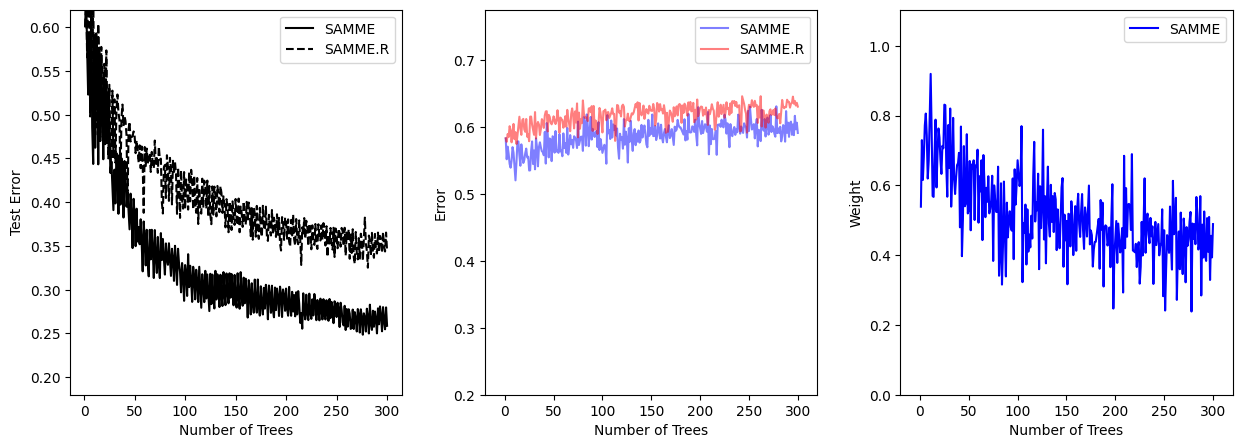

In [29]:
import matplotlib.pyplot as plt

from sklearn.datasets import make_gaussian_quantiles
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier

X, y = make_gaussian_quantiles(n_samples=13000, n_features=10, n_classes=3, random_state=1)
n_split = 3000

X_train, X_test = X[:n_split], X[n_split:]
y_train, y_test = y[:n_split], y[n_split:]

bdt_real = AdaBoostClassifier(DecisionTreeClassifier(max_depth=2), n_estimators=300, learning_rate=1)

bdt_discrete = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=2),
    n_estimators=300,
    learning_rate=1.5,)

bdt_real.fit(X_train, y_train)
bdt_discrete.fit(X_train, y_train)

real_test_errors = []
discrete_test_errors = []

for real_test_predict, discrete_test_predict in zip(bdt_real.staged_predict(X_test), bdt_discrete.staged_predict(X_test)):
    real_test_errors.append(1.0 - accuracy_score(real_test_predict, y_test))
    discrete_test_errors.append(1.0 - accuracy_score(discrete_test_predict, y_test))

n_trees_discrete = len(bdt_discrete)
n_trees_real = len(bdt_real)

# 提升会提前终止，数组是n_estimators长。按照实际树的数量进行修剪
discrete_estimator_errors = bdt_discrete.estimator_errors_[:n_trees_discrete]
real_estimator_errors = bdt_real.estimator_errors_[:n_trees_real]
discrete_estimator_weights = bdt_discrete.estimator_weights_[:n_trees_discrete]

plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.plot(range(1, n_trees_discrete + 1), discrete_test_errors, c="black", label="SAMME")
plt.plot(range(1, n_trees_real + 1), real_test_errors, c="black", linestyle="dashed", label="SAMME.R",)
plt.legend()
plt.ylim(0.18, 0.62)
plt.ylabel("Test Error")
plt.xlabel("Number of Trees")

plt.subplot(132)
plt.plot(range(1, n_trees_discrete + 1), discrete_estimator_errors, "b", label="SAMME", alpha=0.5,)
plt.plot(range(1, n_trees_real + 1), real_estimator_errors, "r", label="SAMME.R", alpha=0.5)
plt.legend()
plt.ylabel("Error")
plt.xlabel("Number of Trees")
plt.ylim((0.2, max(real_estimator_errors.max(), discrete_estimator_errors.max()) * 1.2))
plt.xlim((-20, len(bdt_discrete) + 20))

plt.subplot(133)
plt.plot(range(1, n_trees_discrete + 1), discrete_estimator_weights, "b", label="SAMME")
plt.legend()
plt.ylabel("Weight")
plt.xlabel("Number of Trees")
plt.ylim((0, discrete_estimator_weights.max() * 1.2))
plt.xlim((-20, n_trees_discrete + 20))

# 防止y轴标签重叠
plt.subplots_adjust(wspace=0.25)
plt.show()


<div style="text-align: center;">图6-11  多分类问题SAMME算法和SAMME.R算法的性能

>**结果解析**  
>- **测试错误率（左图）**：  
展示了随着基分类器数量增加，测试错误率的变化。  
>**可以观察到**：  
两种配置的错误率都随迭代次数增加而下降。  
更高学习率（1.5）的配置可能收敛更快，但波动更大。  
最终错误率趋于稳定。  

>- **基分类器错误率（中图）**：  
显示每个基分类器在加权训练集上的错误率。  
>**可以观察到**：  
错误率随迭代波动。  
AdaBoost会调整样本权重，使得后续基分类器更关注之前分类错误的样本。  

>- **基分类器权重（右图）**：  
显示每个基分类器在最终集成模型中的权重。  
>**可以观察到**：  
权重分布不均匀。  
对提升整体性能贡献大的基分类器会被赋予更高权重。  

**例6-5** 在具有少量<font color='red'>高斯噪声</font>的一维正弦数据集上使用**AdaBoost.R2算法**提升决策树。299次提升（300棵决策树）与单棵决策树回归器进行比较。随着提升次数的增加，回归器可以拟合更多细节，如图6-12 所示。

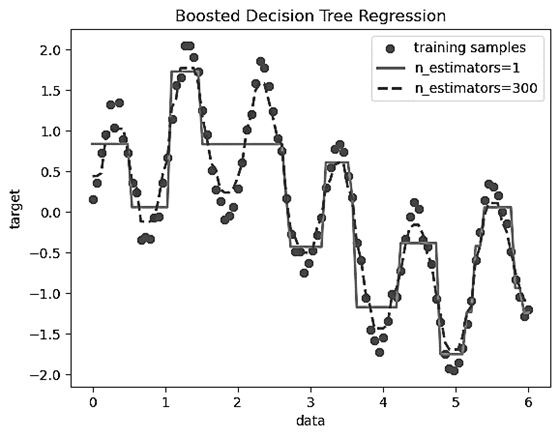
<div style="text-align: center;">图6-12  AdaBoost决策树回归

**例6-5：AdaBoost决策树回归**

> 本示例演示了如何使用AdaBoost增强决策树回归器来拟合带有噪声的非线性数据（正弦波组合），并与单棵决策树的回归效果进行对比。  

>**数据特性**：  
人工合成的正弦波组合数据（y = sin(X) + sin(6X)）  
添加高斯噪声（μ=0, σ=0.1）模拟真实场景  
>**模型对比**：  
单棵决策树回归（max_depth=4）  
AdaBoost回归（300棵max_depth=4的决策树集成）  

第一步，准备具有<font color='red'>正弦关系</font>和一些<font color='red'>高斯噪声</font>的合成数据。

In [30]:
import numpy as np  
  
rng = np.random.RandomState(1)    
X = np.linspace(0, 6, 100)[:, np.newaxis]   
y = np.sin(X).ravel() + np.sin(6 * X).ravel() + rng.normal(0, 0.1, X.shape[0])   


第二步，使用<font color='red'>决策树</font>和<font color='red'>AdaBoost回归器</font>进行训练与预测。  

>首先定义**决策树回归器regr_1**和**AdaBoost回归器regr_2**并拟合数据；然后对相同的数据进行预测，看看它们能在多大程度上拟合数据。**regr_1**是一个具有<font color='red'>max_depth=4</font>的DecisionTreeRegressor；**regr_2**是一个具有<font color='red'>max_depth=4</font>，<font color='red'>以DecisionTreeRegressor为基学习器</font>的**AdaBoost回归器**，在该AdaBoost回归器中，设置<font color='red'>n_estimators=300</font>实现构建。


In [31]:
from sklearn.ensemble import AdaBoostRegressor  
from sklearn.tree import DecisionTreeRegressor  
  
regr_1 = DecisionTreeRegressor(max_depth=4)  
regr_2 = AdaBoostRegressor(DecisionTreeRegressor(max_depth=4), n_estimators=300, random_state=rng)  
  
regr_1.fit(X, y)  
regr_2.fit(X, y)   
  
y_1 = regr_1.predict(X)  
y_2 = regr_2.predict(X)  


第三步，绘制**单棵决策树回归器**和**AdaBoost回归器**的结果，展示其对数据的拟合程度。

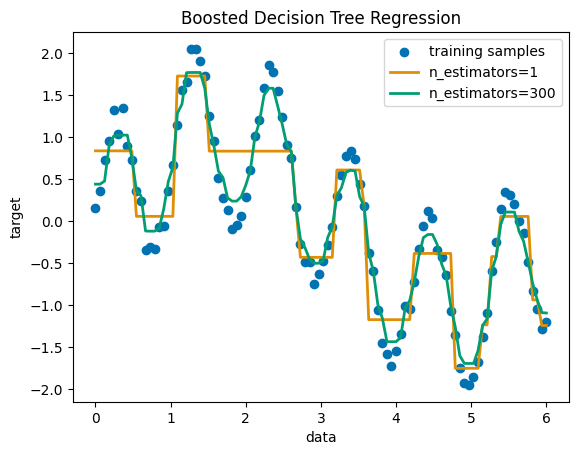

In [47]:
import matplotlib.pyplot as plt  
import seaborn as sns  
  
colors = sns.color_palette("colorblind")  
plt.figure()  
plt.scatter(X, y, color=colors[0], label="training samples")  
plt.plot(X, y_1, color=colors[1], label="n_estimators=1", linewidth=2)  
plt.plot(X, y_2, color=colors[2], label="n_estimators=300", linewidth=2)  
plt.xlabel("data")  
plt.ylabel("target")  
plt.title("Boosted Decision Tree Regression")  
plt.legend()  
plt.show()  


>**结果解析**  

>**1. 拟合效果对比**：  
| 模型	| 优点 | 缺点 |
| :--- | :--- | :--- |
| 单棵决策树 (regr_1) | 计算速度快 | 明显欠拟合，无法捕捉复杂模式 |
| AdaBoost (regr_2)	| 更好地拟合正弦波动	| 计算成本较高 |

>**2. 关键观察**  
**单棵决策树**：  
呈现分段常数预测（决策树的典型特征）  
深度限制导致无法捕捉高频变化（sin(6X)部分）  
>**AdaBoost回归**：   
通过集成300棵弱学习器，显著提升拟合能力。  
能较好还原原始正弦组合波形。  
对噪声具有鲁棒性（未出现过拟合）。  

>**3. 可视化解读**  
> 蓝色散点：带噪声的训练数据。  
橙色线：单棵决策树的欠拟合预测。  
绿色线：AdaBoost的良好拟合。  

### <font color='blue' >6.5.2  算法小结</font>

由上述内容可知，**AdaBoost算法**特点主要如下。

- 必须使用同一种基学习器。  
- 将所有弱分类器联合起来，分类效果好的分类器具有较大的权重，分类效果差的分类器具有较小的权重。  
- 样本权重的更新规则是对分类错误的样本，增大其权重；对分类正确的样本，减小其权重；错误分类的样本点将在下一轮次训练中收到更大的关注。  
- 基于指数型的损失函数。  


## <font color='blue' >进阶F  AdaBoost算法伪代码</font>

AdaBoost算法伪代码如算法6-1所示。
***

**算法6-1：AdaBoost算法**

输入：训练集 $T=\left[(x_1,y_1),(x_2,y_2),\ldots,(x_N,y_N)\right],x_i \in \chi \subseteq \rm \mathbf{R}^n$，$y_i \in \rm{Y} =\{-1,1\}$ ；弱学习算法  
输出：最终分类器 $G(x)$

Step1  初始化训练样本的权重分布：

<div style="text-align: center;"> $D_1=\left(w_{11},w_{12},\ldots, w_{1i},\ldots,w_{1N}\right)$ $ w_{1i}= \frac 1 N $ ， $i=1,2,\ldots,N$ <div>

Step2   For $m=1,2,\ldots,M$

2.1  在权重分布为 $D_m$ 的数据集上训练，得到基分类器

<div style="text-align: center;">  $G_m(x):{\chi} \to \{-1,1\}$<div>

2.2  基分类器 $G_m(x)$ 在训练数据集上的分类误差率为

<div style="text-align: center;">$e_m=P\left(G_m(x_i)\neq y_i\right)= \sum_{i=1}^N w_{mi}I\left(G_m(x_i)\neq y_i\right)$

2.3  计算 $G_m(x)$ 的系数 $a_m=\frac{1}{2} \ln \frac{1-e_m}{e_m}$ 。

2.4  更新数据集的权重分布：

<div style="text-align: center;"> $D_{m+1}=(w_{m+1,1},w_{m+1,2},\ldots,w_{m+1,i},\ldots,w_{m+1,N})$

<div style="text-align: center;">$w_{m+1,i}=\frac{w_{mi}}{Z_m}exp\left[-a_m y_i G_m(x_i)\right]$

<div style="text-align: center;">$Z_m=\sum_{i=1}^N w_{mi} exp\left[-a_m y_i G_m(x_i)\right]$

其中， $Z_m$ 是规范化因子，使得 $D_{m+1}$ 服从一个概率分布。

Step3  构建基分类器的线性组合$f(x)=\sum_{i=1}^{N}a_m G_m(x)$，得到最终分类器：

<div style="text-align: center;">$G(x)=sign\left[f(x)\right]=sign\left[\sum_{i=1}^Na_m G_m(x)\right]$   

***

## <font color='blue' >6.6　GBDT算法</font>

**梯度提升**（Gradient Boosting）也是一种常用的**Boosting方法**，其主要思想是，每次<font color='red'>新建立模型都是在之前建立模型的损失函数的梯度下降方向上进行迭代</font>。已知<font color='red'>损失函数描述的是模型的不靠谱程度</font>，损失函数值越大，说明模型越容易出错。如果模型能够让损失函数值持续减小，则说明模型在不断得到改进，而最好的方式就是让损失函数在其负梯度（Gradient）的方向上下降。

基于Boosting框架的整体模型使用一个线性组合来表示，即 

<div style="text-align: center;">$F(x)=\sum_{i=1}^{M}h_i(x)$

其中，$h_i(x)$ 为基学习器与其权重的乘积； $M$ 为基学习器（也称弱学习器）的数量，也是迭代次数，该模型在训练集 $\{(x_i,y_i)\}_{i=1}^n$ 中进行学习，下面为了描述简洁，有时直接使用没有下标的 $(x,y)$ 表示这个训练集；$f_m$ 为第 $m$ 个弱学习器；$F_m$ 为前 $m$ 个弱学习器的组合。该模型还有一个可微的损失函数 $L(y,F(x))$ 。

整体模型的训练目标是使其预测值 $F(x)$ 逼近真实值 $y$ ，即让每个基学习器的预测值逼近各自要预测部分的真实值。如果同时考虑所有基模型，则将导致整体模型的训练变成一个非常复杂的问题。为此，研究者提出了一个<font color='red'>贪心方法</font>，每次只训练一个基模型，整体模型改写为一个<font color='red'>迭代式</font>：

<div style="text-align: center;">$F_i(x)=F_{i-1}x+h_i(x)$

在该算法的每次迭代中，其仅集中解决一个基模型的训练问题，使 $F_i(x)$ 更逼近真实值 $y$ ，即使 $h_i(x)$ 逼近残差 $y-F_{i-1}(x)$ 。一种直接的做法是构建一个基模型来<font color='red'>拟合残差</font>。残差其实是平方差损失函数关于预测值的负梯度：

<div style="text-align: center;">$\frac{\partial\{\frac{1}{2}[y-F_{i-1}(x)]^2\}}{\partial F(x)}=y-F_{i-1}(x)$

也就是说，若 $F_{i-1}(x)$加上拟合负梯度的 $h_i(x)$ 得到 $F_i(x)$ ，则将导致平方差损失函数值减小，预测的准确度提高。

由上所知，**梯度提升算法**作为经典的提升方法之一，它与**AdaBoost**一样都是将弱学习器组合成强学习器，两者的**区别**主要有：
- **梯度提升法**通过<font color='red'>梯度下降法学习损失函数生成下一个模型</font>，而**AdaBoost**则<font color='red'>利用前一轮的弱学习器的误差改变样本的权重</font>进行学习；
- **梯度提升法**接入的弱学习器一般是一颗完整的决策树，而**AdaBoost**理论上并不局限于决策树。

**梯度树提升**或**梯度提升决策树**（Gradient Boosting Decision Tree，**GBDT**）是针对任意可微损失函数的提升的推广。**GBDT**从名称上讲包含两部分：<font color='red'>决策树</font>和<font color='red'>梯度提升</font>。决策树我们都比较熟悉了。由前所述，**梯度提升法**是指基于一组弱学习器，使用<font color='red'>梯度信息</font>对弱学习器的结果进行加权，得到一个性能比较好的学习器。该方法的弱学习器通常是层数较少的CART，单个弱学习器因<font color='red'>层数少</font>而<font color='red'>偏差较大</font>、<font color='red'>方差小</font>；最终的GBDT的输出是将不同的决策树的预测值进行叠加，从而获得较好的性能，如图6-13 所示。

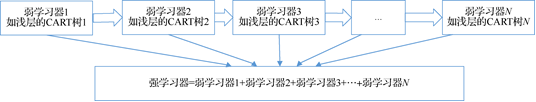
<div style="text-align: center;">图6-13  GBDT框架

**算法6-2**  给出了GBDT求解回归问题的伪代码，呈现其处理步骤。
***

**算法6-2：GBDT算法**

输入：训练集$\{\left(x_i,y_i\right)\}_{i=1}^n$ ，一个可微的损失函数 $L\left(y,F(x)\right)$ ，迭代次数为 $M$ ，记 $f_m$ 为第 $m$ 个弱学习器，$F_m$ 是前 $m$ 个弱学习器的组合  
输出：回归树 $F_M(x)$


Step1  常值初始化第0个弱学习器：

<div style="text-align: center;"> $F_0(x)=f_0(x)=\arg\min_c \sum_{i=1}^N L(y_i,c)=\frac{\left(\sum_{i=1}^N y_i \right)}{N}=\overline{y},i=1,2,\ldots,n$

Step2  For $m$ = 1 to $M$ ：

Step2.1  计算残差：

<div style="text-align: center;">$r_{im}=-\left[\frac{\partial L\left(y_i,F(x_i)\right)}{\partial F(x_i)}\right]_{F(x_i)=F_{m-1}(x_i)}=y_i-F_{m-1}(x_i),i=1,2,\ldots,n$

Step2.2  构建新数据集 $\{(x_i,r_{im})\}_{i=1}^n$ 并拟合一个弱学习器 $h_m(x)$

Step2.3  通过求解下面的一维优化问题计算乘子$\gamma_m$ ：

<div style="text-align: center;">$\gamma_m=\arg\mathop{\min}\limits_{\gamma} \sum_{i=1}^n L\left(y_i,F_{m-1}(x_i)+\gamma h_m(x)\right)$

Step2.4　更新模型：

<div style="text-align: center;">$F_m(x)=F_{m-1}(x)+\gamma_m h_m(x)$

Step3  输出$F_M(x)$
***

下面通过一个例子来讲解GBDT算法的步骤，便于读者理解。我们使用“年龄”和“体重”特征预测最终的身高，如表6-1所示。

<div style="text-align: center;">表6-1  初始数据集<div>
    
| 编号 | 年龄 | 体重/kg | 身高/m |
|:--- |:--- |:--- |:--- |
| 1 | 10 | 40 | 1 |
| 2 | 12 | 50 | 1.4 |
| 3 | 15 | 50 | 1.6 |
| 4 | 18 | 60 | 1.7 |
| 5 | 20 | 60 | ? |

假设构建两棵树，每棵树的<font color='red'>深度</font>为3，同时设置<font color='red'>学习率</font>为0.1。

第一步，初始化弱学习器：

<div style="text-align: center;">$c=\overline{y}=\frac{\left(\sum_{i=1}^N y_i\right)}{N}=\frac{1+1.4+1.6+1.7}{4}=1.425$

第二步，计算残差，开始迭代构建决策树1。

根据初始弱学习器 $c=1.425$，计算样本残差，如表6-2 的 $y-c$ 列。该列为在新一轮迭代中需要学习的残差。

表6-2 中的样本有2个特征，7种取值。在CART回归树中，当节点分裂时，有7种可能性，选择可以<font color='red'>使最终分裂结果加权方差最小的特征值</font>作为最终的<font color='red'>分裂值</font>，如表6-3 所示。

<div style="text-align: center;">表6-2  含残差数据集<div>
    
| 编号 | 年龄 | 体重/kg | y-c |
|:--- |:--- |:--- |:--- |
| 1 | 10 | 40 | -0.425 |
| 2 | 12 | 50 | -0.025 |
| 3 | 15 | 50 | 0.175 |
| 4 | 18 | 60 | 0.275 |

<div style="text-align: center;">表6-3  分裂节点计算<div>

| 分裂点 | <分裂点 | 左y-c平均值 | $\geq$分裂点 |  右y-c平均值 | $\rm SE_l$ | $\rm SE_r$ | 加权方差$\rm SE_{sum}$ |
|:--- |:--- |:--- |:--- |:--- |:--- |:--- |:--- |
| 年龄10 | -  | 0  | 1,2,3,4  | 0 | 0 | 0.2875 | 0.2875 |
| 年龄12 | 1 | -0.425 | 2,3,4 | 0.142 | 0 | 0.047 | 0.035 |
| 年龄15 | 1,2 | -0.225 | 3,4 | 0.225 | 0.08 | 0.005 | 0.0425 |
| 年龄18 | 1,2,3 | -0.092 | 4 | 0.275 | 0.187 | 0 | 0.14 |
| 体重40 | -|  0 | 1,2,3,4 | 0 | 0 | 0.2875	| 0.2875 |
| 体重50 | 1 | -0.425 | 2,3,4 | 0.142 | 0 | 0.047 | 0.035 |
| 体重60 | 1,2,3 | -0.092 | 4 | 0.275 | 0.187 | 0 | 0.14 |

如表6-3 所示，按照“年龄12”和“体重50”分裂的结果的加权方差都是最小的，随机选择“年龄12”，如图6-14 所示。

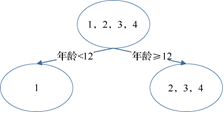
<div style="text-align: center;">图6-14  决策树1一次分裂<div>

由于设置的树的深度为3，因此还需要分裂一次，仍然使用表6-2 中的残差值 为要学习的真实值。因为左侧节点只有一个样本，无法再分裂，所以只分裂右侧节点。与前述步骤一样，选择使得最终分裂结果加权方差最小的特征值作为最终的分裂值

如表6-4 所示，右侧节点分裂，按照“年龄15”进行分裂，最终的加权方差值最小。相应的决策树 如图6-15 所示。

<div style="text-align: center;">表6-4  右侧节点分裂计算<div>

| 分裂点 | <分裂点 | 左y-c平均值 | $\geq$分裂点 |  右y-c平均值 | $\rm SE_l$ | $\rm SE_r$ | 加权方差$\rm SE_{sum}$ |
|:--- |:--- |:--- |:--- |:--- |:--- |:--- |:--- |
| 年龄15 | 2 | -0.225 | 3,4 | 0.225 | 0.0 | 0.005 | 0.003 |
| 年龄18 | 2,3 | 0.075 | 4 | 0.275 | 0.02 | 0 | 0.13 |
| 体重50 | - | - | 2,3,4 | 0.142 | 0 | 0.047 | 0.047 |
| 体重60 | 2,3 | 0.075 | 4 | 0.275 | 0.02 | 0 | 0.13 |

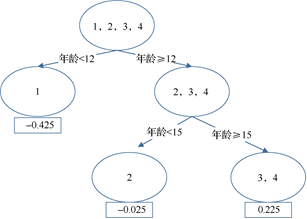
<div style="text-align: center;">图6-15  决策树1二次分裂<div>

第一轮迭代后，根据**决策树** $h_1(x)$ 和初始**弱学习器** $F_0(x)$ ，可得**集成强学习器**为

$F_1(x)=F_0(x)+$learnin_rate$\gamma_1 h_1(x)$

其中，$F_0(x)=c=1.425$ ， **learnin_rate**是学习率，在迭代中设为0.1。

第三步，计算**残差**，开始迭代构建**决策树2**。

在第二轮迭代中，需要使用第一轮迭代结束时得到的**强学习器**重新预测每个样本的结果， $y-F_1(x)$为新的要拟合的**残差**。计算过程和构建第1棵决策树的过程一样，得到一棵新的**决策树2**，并**更新强学习器**即可，具体计算过程这里不再赘述。

由伪代码和实例可知，**GBDT**在当前轮的弱学习器中，以 $\{(x_i,\tilde{y}_i)\}_{i=1}^n$ 为训练数据构建第 $m$ 个**决策树** $f_m$ 以**拟合损失函数的负梯度值**$\tilde{y}_i=y_i-F_{m-1}(x_i)$ ，该负梯度值由当前集成的**强学习器** $F_{m-1}(x_i)=\sum_{i=1}^{m-1}f_i(x_i)$给出。该组合方式是简单的加法模型或加入学习率后的加法模型（防止过拟合）。 $F_M(x)=F_{M-1}(x)+f_M(x)=\sum_{i=1}^{M}f_i(x)$为最终得到的**强学习器**。

sklearn.ensemble模块提供了GBDT分类和回归方法，其调用步骤如下。

In [50]:
# 调取sklearn包
# 在sklearn中，线性回归模型在linear_model模块中
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor 
from sklearn import tree
# 调取sklearn包中自带的数据集
from sklearn.datasets import load_iris  #调用鸢尾花数据集

X1, y1 = load_iris(return_X_y=True)  #获取X、y数据

rfc =  GradientBoostingClassifier()  #初始化一个随机森分类模型
rfr = GradientBoostingRegressor()   #初始化一个随机森林回归模型

rfc.fit(X1,y1) #fit()函数用于训练


GradientBoostingClassifier()

本节除了介绍**GBDT分类和回归方法**，还引入了两种新的**梯度提升树**，分别是<font color='red'>HistGradientBoostingClassifier</font>和<font color='red'>HistGradient BoostingRegressor</font>。当样本数量大于数万个时，<font color='red'>基于直方图的估计器</font>可以比<font color='red'>GradientBoostingClassifier</font>和<font color='red'>GradientBoostingRegressor</font>的速度快几个数量级。基于直方图的梯度提升方法的详细描述可参阅6.7节和相关资料。

本节内容侧重于GradientBoostingClassifier和GradientBootingRegressor，这可能是小样本量的首选，因为在这种设置下，箱化可能会导致过于近似的分割点。

GradientBoostingClassifier和GradientBooatingRegressor的用法和参数如下所述。这些估计器的两个最重要的参数是<font color='red'>n_estimators</font>与<font color='red'>learning_rate</font>。

### <font color='blue' >6.6.1   分类和回归</font>

**GradientBoostingClassifier**同时支持<font color='red'>二分类</font>和<font color='red'>多分类</font>。以下代码片段显示了如何对具有100棵决策树（作为弱学习器）的梯度提升分类器进行<font color='red'>拟合</font>。

In [49]:
from sklearn.datasets import make_hastie_10_2
from sklearn.ensemble import GradientBoostingClassifier

X, y = make_hastie_10_2(random_state=0)
X_train, X_test = X[:2000], X[2000:]
y_train, y_test = y[:2000], y[2000:]

clf = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0).fit(X_train, y_train)
clf.score(X_test, y_test)


0.913

**1．控制树的大小**

**回归树基学习器**的大小定义了由**梯度提升模型**捕获的**变量交互水平**。通常，深度为h的树可以捕获h阶的交互，h从0开始计数。有两种方法可以控制各回归树的大小。

如果指定<font color='red'>max_depth=h</font>，则生长深度为h的完全二叉树将具有（最多） $2^h$ 个叶节点和 $2^{h-1}$ 个分裂节点。或者，可以通过**参数max_leaf_nodes**指定叶节点的数量来控制树的大小。在这种情况下，将使用最优优先搜索来生成树，其中杂质改进最多的节点将首先被扩展。**max_leaf_nodes=k**的树具有k-1个分裂节点，因此可以对高达**max_leaf_nodes-1**阶的交互进行建模。可以发现，max_leaf_nodes=k给出了与max_depth=k-1相当的结果，但以稍大的训练误差为代价，训练速度要快得多。由此，**每棵树的大小**可以通过由<font color='red'>max_depth设置的树深度</font>或由<font color='red'>max_leaf_nodes设置的叶节点的数量</font>来控制。

除了控制一颗树的大小，还可以通过**参数n_estimators**<font color='red'>设置弱学习器的数量</font>；**learning_rate**是一个在（0.0,1.0]区间的超参数，用于<font color='red'>控制收敛速度</font>。

在**多分类任务**中，每次迭代都需要引入**n_classes**棵回归树，因此，引入树的总数等于**n_classes n_estimators**。对于具有大类别的数据集，强烈建议使用后面引入的**HistGradientBoostingClassifier**作为**GradientBootingClassifier**的替代方案。

**2．损失函数**

**GradientBoostingRegressor**支持许多不同的**回归损失函数**，这些函数可通过**参数loss**来指定，默认的**损失函数**是**平方误差**（'squared_error'）。

针对<font color='red'>回归问题</font>，该类算法支持的损失函数如下。
- **平方误差**：由于其优越的计算特性而成为用于回归的一种自然的选择。初始模型由目标值的平均值给出。  
- **绝对误差**（'absolute_error'）：用于回归的一种鲁棒的损失函数。初始模型由目标值的中值给出。  
- **Huber**（'huber'）：另一个结合了最小二乘法和最小绝对偏差的鲁棒的损失函数，使用alpha来控制异常值的敏感性。  
- **分位数**（'quantile'）：分位数回归的损失函数。0＜alpha＜1被用指定分位数。此损失函数还可用于创建预测区间。  


针对<font color='red'>分类问题</font>，该类算法支持的损失函数如下。
- **二分类对数损失**（'log-loss'）：用于二分类的二项式负对数似然损失函数。它提供了概率估计。
- **多分类对数损失**（'log-loss'）：用于具有n_classes个互斥类别的多分类的多项式负对数似然损失函数。它提供了概率估计。初始模型由每个类别的先验概率给出。在每次迭代中，必须构建n_classes棵回归树，这使得GBRT对具有大量类别的数据集来说效率相当低。
- **指数损失**（'exponential'）：与AdaBoostClassifier相同的损失函数。与二分类对数损失相比，其对误标记的样本的鲁棒性较差，只能用于二分类。


In [50]:
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_friedman1
from sklearn.ensemble import GradientBoostingRegressor

X,y = make_friedman1(n_samples=1200,random_state=0,noise=1.0)
X_train, X_test = X[:200], X[200:]
y_train, y_test = y[:200], y[200:]
est = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=1, random_state=0, loss='squared_error').fit(X_train, y_train)
mean_squared_error(y_test, est.predict(X_test))


5.009154859960321

GradientBoostingRegressor和GradientBooatingClassifier均支持通过设置warm_start=True来允许向已拟合的模型添加更多估计器。

In [51]:
_ = est.set_params(n_estimators=200, warm_start=True)  
_ = est.fit(X_train, y_train)  
mean_squared_error(y_test, est.predict(X_test))

3.840234741105356

### <font color='blue' >6.6.2  GBDT 实践</font>

由6.6.1节所知，**梯度提升**可用于<font color='red'>回归</font>和<font color='red'>分类</font>问题。例6-6展示了使用**最小二乘损失**和500个**基学习器**的**GradientBoostingRegressor**应用于<font color='red'>糖尿病数据集（sklearn.datasets.load_dabetes）</font>的情况。图6-16显示了每次迭代的**训练误差**和**测试误差**。每次迭代的训练误差存储在**梯度提升模型**的**train_score_属性**中。每次迭代的测试误差可以通过**staged_predict()方法**获得，该方法返回在每个阶段产生预测的**生成器**。

**例6-6：梯度提升回归**。

>本例描述了如何训练一个模型来处理**糖尿病回归任务**。这里从使用**最小二乘损失**和具有深度为4的500棵回归树的**GradientBoostingRegressor**中获得结果。  
注：对于较大的数据集（n_samples≥10000），请参阅HistGradientBoostingRegressor。

加载糖尿病数据集（datasets.load_diabetes()）:

In [51]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import datasets, ensemble
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
diabetes = datasets.load_diabetes()  # 加载数据
X, y = diabetes.data, diabetes.target


**算法步骤**

第一步，<font color='red'>数据预处理</font>。  

><font color='red'>拆分数据集</font>，90%用于训练，其余用于测试。而且，<font color='red'>设置回归模型参数</font>，并且可以通过调整以下这些参数来查看结果如何变化：   
>- **n_estimators**：将要执行的提升阶段的数量，即基学习器的数量。稍后，针对提升迭代绘制偏差。  
>- **max_depth**：限制树中节点的数量。最优值取决于输入变量的交互作用。  
>- **min_samples_split**：拆分内部节点所需的最小样本数。  
>- **learning_rate**：每棵树的提升作用将减少多少，即**学习率**。  
>- **loss**：要优化的损失函数。在本例中，使用最小二乘损失函数（还有许多其他选项）。  


In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=13)
params = {"n_estimators": 500, "max_depth": 4, "min_samples_split": 5, "learning_rate": 0.01, "loss": "squared_error",}


第二步，<font color='red'>拟合回归模型</font>。  

>**模型训练与评估**：
>- 初始化<font color='red'>GradientBoostingRegressor</font>并传入参数。  
>- 使用训练数据（X_train和y_train）拟合模型。  
>- 在测试集上计算均方误差（MSE）以评估模型性能。  

In [54]:
reg = ensemble.GradientBoostingRegressor(**params)
reg.fit(X_train, y_train)

mse = mean_squared_error(y_test, reg.predict(X_test))
print("The mean squared error (MSE) on test set: {:.4f}".format(mse))


The mean squared error (MSE) on test set: 3011.9966


第三步，<font color='red'>绘制训练偏差</font>。

>为了将结果可视化：  
>- 首先，计算测试集在每一轮提升迭代（boosting iteration）后的偏差（MSE）。
>- 然后，绘制训练集和测试集的偏差随提升迭代的变化曲线，观察模型是否过拟合或欠拟合。

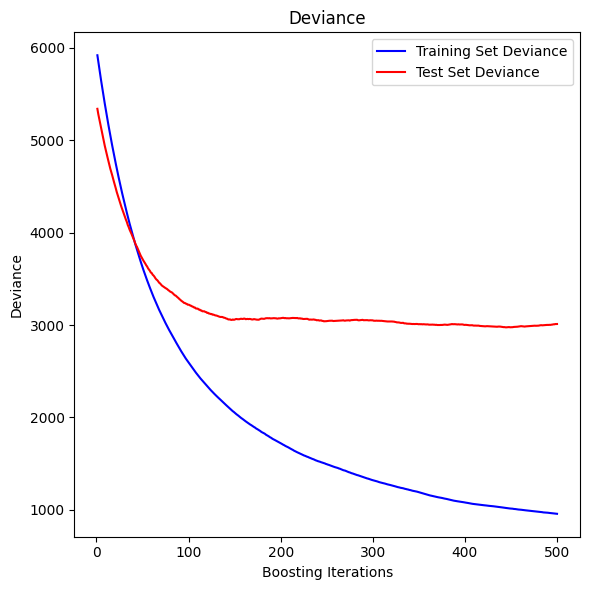

In [55]:
test_score = np.zeros((params["n_estimators"],),dtype=np.float64)
for i, y_pred in enumerate(reg.staged_predict(X_test)):
    test_score[i] = mean_squared_error(y_test, y_pred)

fig = plt.figure(figsize=(6, 6))
plt.subplot(1, 1, 1)
plt.title("Deviance")
plt.plot(np.arange(params["n_estimators"]) + 1, reg.train_score_, "b-", label="Training Set Deviance",)
plt.plot(np.arange(params["n_estimators"]) + 1, test_score, "r-", label="Test Set Deviance")
plt.legend(loc="upper right")
plt.xlabel("Boosting Iterations")
plt.ylabel("Deviance")
fig.tight_layout()
plt.show()


>**结果解析**：
 
>**均方误差（MSE）**：  
测试集的MSE为3025.7877。MSE的值较大，表明模型的预测误差较高，可能与数据集的复杂性或模型参数的选择有关。  
**偏差曲线**：
通过绘制训练集和测试集的偏差曲线，可以观察到：  
训练集的偏差（<font color='blue' >蓝色曲线</font>）随着提升迭代的增加而单调下降，因为模型不断优化训练数据的拟合。  
测试集的偏差（<font color='red' >红色曲线</font>）最初随着迭代增加而下降，但在某个点后可能开始上升或趋于平稳，这表明模型可能在训练集上过拟合。  
如果测试集偏差在某一迭代后开始上升，说明后续的迭代可能导致过拟合，此时可以通过提前停止（early stopping）来优化模型。  

<div style="text-align: center;">图6-16  梯度提升回归示例</div>

## <font color='blue' >6.7　基于直方图的梯度提升</font>

**Scikit-learn 0.21**引入了两种新的<font color='red'>梯度提升树实现</font>，即**HistGradientBoostingClassifier**和**HistGradient BoostingRegressor**。

该类估计器首先将输入样本进行**整数值的箱化**（通常为256个箱），这大大减少了要考虑的分割点的数量，并允许算法在构建树时利用**直方图**，而不依赖排序的连续值。该类估计器的API略有不同，**GradientBoostingClassifier**和**GradientBooatingRegressor**的一些特性尚未得到支持，如一些损失函数。

### <font color='blue' >6.7.1  用法</font>

与GradientBoostingClassifier和GradientBooatingRegressor相比，多数参数都没有变化。一个例外是使用**max_iter参数**取代了**n_estimators**，并控制提升过程中的迭代次数。

In [9]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.datasets import make_hastie_10_2

X, y = make_hastie_10_2(random_state=0)
X_train, X_test = X[:2000], X[2000:]
y_train, y_test = y[:2000], y[2000:]

clf = HistGradientBoostingClassifier(max_iter=100).fit(X_train, y_train)
clf.score(X_test, y_test)


0.8965

对于回归问题，**可用的损失**有'**squared_error**'、'**absolute_error**'（对异常值不太敏感）和'**poisson**'（非常适合建模计数和频率）。对于分类问题，'**log_loss**'是唯一的选项。


对数据进行箱化的箱子数量由**max_bins参数**控制。较少的箱子可作为正则化的一种形式。通常建议使用尽可能多的箱子，这是默认设置。


**1．缺失值支持**

HistGradientBoostingClassifier和HistGradient BoostingRegressor内置了对<font color='red'>缺失值（NaN）</font>的支持。在训练过程中，基于潜在增益，在每个分割点学习具有缺失值的样本应该放在左子节点还是右子节点。预测时，遵循学到的规则，具有缺失值的样本将被分配给左子节点或右子节点。

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier
import numpy as np

X = np.array([0, 1, 2, np.nan]).reshape(-1, 1)
y = [0, 0, 1, 1]

gbdt = HistGradientBoostingClassifier(min_samples_leaf=1).fit(X, y)
gbdt.predict(X)


array([0, 0, 1, 1])

如果在训练过程中没有遇到给定特征的缺失值，则具有缺失值的样本将映射到具有最多样本的子节点。

**2．样本权重支持**

HistGradientBoostingClassifier和HistGradient BoostingRegressor在拟合过程中支持<font color='red'>样本加权</font>。以下代码片段演示了模型如何忽略样本权重为零的样本。

In [54]:
X = [[1, 0], [1, 0], [1, 0], [0, 1]]
y = [0, 0, 1, 0]
sample_weight = [0, 0, 1, 1]
gb = HistGradientBoostingClassifier(min_samples_leaf=1)
gb.fit(X, y, sample_weight=sample_weight)


HistGradientBoostingClassifier(min_samples_leaf=1)

In [12]:
gb.predict([[1, 0]])

array([1])

In [13]:
gb.predict_proba([[1, 0]])[0, 1]

np.float64(0.9990209190235209)

可以看到，样本[1,0]被轻松地归为1类，因为前两个样本的权重为0而被忽略，虽然它们的类别是0类。样本权重支持的具体实现，相当于将**梯度**（和Hessian矩阵）乘以**样本权重**。请注意，bin阶段（特别是分位数计算）没有考虑权重。

随机森林的一个竞争替代方案是基于直方图的**梯度增强（Histogram-Based Gradient Boosting，HGBT）模型**。两者的主要区别如下。

- **构建树**：随机森林通常依赖深度树（单独过拟合），每棵树都是由训练集的替换样本构建的，这需要大量的计算资源，因为它们需要多次拆分和评估候选拆分。HGBT模型构建的浅层树（单独欠拟合）更容易拟合和预测。
- **顺序提升**：在HGBT中，决策树是按顺序构建的，其中每棵树都经过训练以纠正前一棵树所犯的错误。这允许它们使用相对较少的树来迭代地提高模型的性能。相比之下，随机森林使用简单投票策略预测结果，这可能需要更多的树才能达到相同的准确性。
- **高效箱化**：HGBT使用高效直方图箱化算法，可以处理具有大量特征的大型数据集。箱化算法可以对数据进行预处理，以加快后续树的构建。相比之下，随机森林在Scikit-learn中的实现没有使用箱化算法，而是依赖精确拆分，这可能在计算上更耗时。


总体而言，<font color='red'>HGBT与随机森林的计算成本</font>取决于<font color='red'>数据集和建模任务的具体特征</font>。我们应当尝试这两种模型，并比较它们在特定问题上的性能和计算效率，以确定哪种模型最合适，这是一个好主意。

### <font color='blue' >6.7.2  直方图梯度提升模型实践</font>

在例6-7 中，比较了**随机森林**和**HGBT模型**在一个**回归数据集**上的得分与计算时间方面的性能，如图6-17 所示，这里提出的所有概念也适用于分类。

**随机森林**和**HGBT模型**分别通过改变以下<font color='red'>参数</font>来控制<font color='red'>树的数量</font>并进行比较。

- **n_estimators**控制<font color='red'>森林中的树的数量</font>，这是一个固定的数字。
- **max_iter**是**HGBT模型**中的<font color='red'>最大迭代次数</font>。迭代次数对应回归和二元分类问题的树的数量。此外，模型所需的实际树的数量取决于停止标准。


HGBT使用**梯度提升策略**，通过将每棵树<font color='red'>拟合</font>到**损失函数**关于<font color='red'>预测值的负梯度</font>来迭代地提高模型的性能。而**随机森林**则基于<font color='red'>Bagging</font>使用多数投票策略预测结果。

**例6-7：随机森林和HGBT模型的比较。**

>本例的目标是比较两种基于树的集成学习模型——**随机森林**（Random Forest, RF）和**直方图梯度提升树**（HistGradientBoostingRegressor, HGBT）在**加州房价数据集**（California Housing Dataset）上的表现，重点关注它们的训练时间、预测时间、模型精度（R²分数）之间的权衡。

第一步，加载数据集。

>**HGBT**使用一个**基于直方图的算法**实现<font color='red'>箱化特征值</font>，该算法可以有效地处理具有大量特征的大型数据集（数万个样本或更多）。Scikit-learn中的**随机森林模型**没有使用箱化算法，而是依赖精确的拆分，<font color='red'>时间复杂度较高</font>。

>使用<font color='red'>fetch_california_housing</font>加载加州房价数据集，该数据集包含 20,640 个样本和 8 个特征。

In [1]:
from sklearn.datasets._california_housing import fetch_california_housing
X, y = fetch_california_housing(return_X_y=True, as_frame=True)
n_samples, n_features = X.shape
print(f"The dataset consists of {n_samples} samples and {n_features} features")


The dataset consists of 20640 samples and 8 features


第二步，**计算得分和耗时**。

>请注意，<font color='red'>HistGradientBoostingClassifier</font>和<font color='red'>HistGradient BoostingRegressor</font>的许多实现部分在默认情况下是并行的。<font color='red'>RandomForestRegressor</font>和<font color='red'>RandomForestClassifier</font>的实现也可以通过设置**n_jobs参数**在多个核心上运行，该参数设置应与主机上的物理核心数量相匹配。

In [2]:
import joblib

N_CORES = joblib.cpu_count(only_physical_cores=True)
print(f"Number of physical cores: {N_CORES}")


Number of physical cores: 10


与**随机森林**不同，**HGBT模型**提供了<font color='red'>提前停止选项</font>，以避免添加新的不必要的树。在内部，该算法使用<font color='red'>验证集</font>计算每次添加树时模型的<font color='red'>泛化性能</font>。因此，如果在**n_iter_no-change**次迭代以上泛化性能没有得到改善，模型将停止添加树。

>**并行计算设置**  
使用joblib.cpu_count()获取物理核心数（本例为2个），以便在多核CPU上并行训练模型。  
随机森林（RandomForestRegressor）通过n_jobs=N_CORES实现并行化。  
HGBT（HistGradientBoostingRegressor）默认支持并行计算，无需额外设置。  

>**模型参数设置**：  
**随机森林（RF）**：  
min_samples_leaf=5（控制叶子节点最小样本数，防止过拟合）。  
n_estimators=[10, 20, 50, 100]（树的数量）。  
**HGBT**：  
max_leaf_nodes=15（限制每棵树的最大叶子节点数）。  
max_iter=[10, 20, 50, 100, 300, 500]（相当于n_estimators）。  
early_stopping=False（关闭提前停止，便于对比）。

>**交叉验证（CV）**：  
使用KFold(n_splits=4)进行4折交叉验证。  
GridSearchCV搜索最佳超参数，并记录训练时间、预测时间、测试R²分数。  

In [ ]:
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

models = {
    "Random Forest": RandomForestRegressor(min_samples_leaf=5, random_state=0, n_jobs=N_CORES),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(max_leaf_nodes=15, random_state=0, early_stopping=False),}
param_grids = {
    "Random Forest": {"n_estimators": [10, 20, 50, 100]},
    "Hist Gradient Boosting": {"max_iter": [10, 20, 50, 100, 300, 500]},
}

cv = KFold(n_splits=4, shuffle=True, random_state=0)

results = []
for name, model in models.items():
    grid_search = GridSearchCV(estimator=model, param_grid=param_grids[name], return_train_score=True, cv=cv,).fit(X, y)
    result = {"model": name, "cv_results": pd.DataFrame(grid_search.cv_results_)}
    results.append(result)


第三步，**绘制结果**。

>使用**plotly.express.scatter**可视化算法所用的<font color='red'>计算时间</font>和<font color='red'>测试得分平均值</font>之间的权衡。将光标移到给定点上会显示相应的参数。绘制训练时间 vs 测试R²分数 和 预测时间 vs 测试R²分数 的散点图，误差条对应交叉验证的不同折中计算的一个标准偏差。  

>通过交互式可视化展示不同参数下模型的性能表现，便于比较两种算法的效率与精度。  

In [ ]:
import plotly.colors as colors
import plotly.express as px
from plotly.subplots import make_subplots

fig = make_subplots(rows=1, cols=2, shared_yaxes=True, subplot_titles=["Train time vs score", "Predict time vs score"],)
model_names = [result["model"] for result in results]
colors_list = colors.qualitative.Plotly * (len(model_names) // len(colors.qualitative. Plotly) + 1)

for idx, result in enumerate(results):
    cv_results = result["cv_results"].round(3)
    model_name = result["model"]
    param_name = list(param_grids[model_name].keys())[0]
    cv_results[param_name] = cv_results["param_" + param_name]
    cv_results["model"] = model_name

    scatter_fig = px.scatter(
        cv_results,
        x="mean_fit_time",
        y="mean_test_score",
        error_x="std_fit_time",
        error_y="std_test_score",
        hover_data=param_name,
        color="model",)
    line_fig = px.line(cv_results, x="mean_fit_time", y="mean_test_score",)

    scatter_trace = scatter_fig["data"][0]
    line_trace = line_fig["data"][0]
    scatter_trace.update(marker=dict(color=colors_list[idx]))
    line_trace.update(line=dict(color=colors_list[idx]))
    fig.add_trace(scatter_trace, row=1, col=1)
    fig.add_trace(line_trace, row=1, col=1)

    scatter_fig = px.scatter(
        cv_results,
        x="mean_score_time",
        y="mean_test_score",
        error_x="std_score_time",
        error_y="std_test_score",
        hover_data=param_name, )
    line_fig = px.line(cv_results, x="mean_score_time", y="mean_test_score",)

    scatter_trace = scatter_fig["data"][0]
    line_trace = line_fig["data"][0]
    scatter_trace.update(marker=dict(color=colors_list[idx]))
    line_trace.update(line=dict(color=colors_list[idx]))
    fig.add_trace(scatter_trace, row=1, col=2)
    fig.add_trace(line_trace, row=1, col=2)

fig.update_layout(
    xaxis=dict(title="Train time (s) - lower is better"),
    yaxis=dict(title="Test R2 score - higher is better"),
    xaxis2=dict(title="Predict time (s) - lower is better"),
    legend=dict(x=0.72,y=0.05,traceorder="normal",borderwidth=1),
    title=dict(x=0.5, text="Speed-score trade-off of tree-based ensembles"),)


>**结果解析**  
>1. **训练时间 vs 测试R²分数**  
**随机森林（RF）**：  
训练时间较短（n_estimators较少时），但随着树的数量增加，训练时间线性增长。  
R²分数在n_estimators=50~100时趋于稳定，说明增加更多树对模型提升有限。  
**HGBT**：  
训练时间比RF长（因为梯度提升是串行训练树）。  
R²分数随max_iter增加而提升，但计算成本较高。  

>2. **预测时间 vs 测试R²分数**  
**随机森林（RF）**：  
预测时间较短（因为树可以并行预测）。  
但R²分数可能低于HGBT（梯度提升通常更精确）。  
**HGBT**：  
预测时间比RF稍长（因为需要顺序计算每棵树的贡献）。  
但通常能达到更高的R²分数（梯度提升优化更精细）。

>3. 关键结论
| 模型 | 训练时间 | 预测时间 | 精度（R²） | 适用场景 |
| :--- | :--- | :--- | :--- | :--- |
| 随机森林（RF）	| 较短（并行） | 短（并行预测） | 中等 | 快速训练、大规模数据 |
| HGBT | 较长（串行） | 稍长 | 较高 | 高精度需求、可接受较长训练时间 |

>如果计算资源有限（如CPU核心少），RF更合适。  
如果追求更高精度，HGBT更优（但训练时间更长）。  
HGBT更适合大数据（n_samples > 10,000），因为它的直方图分箱（binning）优化了计算效率。  

当在**集成学习器**中增加<font color='red'>树的数量</font>时，**HGBT**和**随机森林模型**都会得到改进。然而，当得分达到一个平稳期时，添加新的树只会使拟合和得分变得更慢。随机森林模型更早达到这样的平稳期，永远无法达到HGBT模型的最大的测试分数。  




请注意，图6-17 中显示的结果可能会在不同的运行中发生明显变化，在其他机器上运行时变化可能会更大，请尝试在自己的本地机器上运行此示例。 

总的来说，可以经常观察到，在训练时间与得分的权衡中，**HGBT模型**的曲线应该在随机森林曲线的左上角，且不会交叉；说明**HGBT模型**均优于**随机森林模型**。在预测时间与得分的权衡中也可能更有争议，但它通常对**HGBT**更有利。检查这两种模型，通过超参数调整，并比较它们在特定问题上的性能总是一个好主意，以确定哪种模型最合适，但**HGBT**几乎总是比**随机森林**提供更有利的速度-精度权衡，无论是使用默认的超参数还是包括超参数调优成本。  

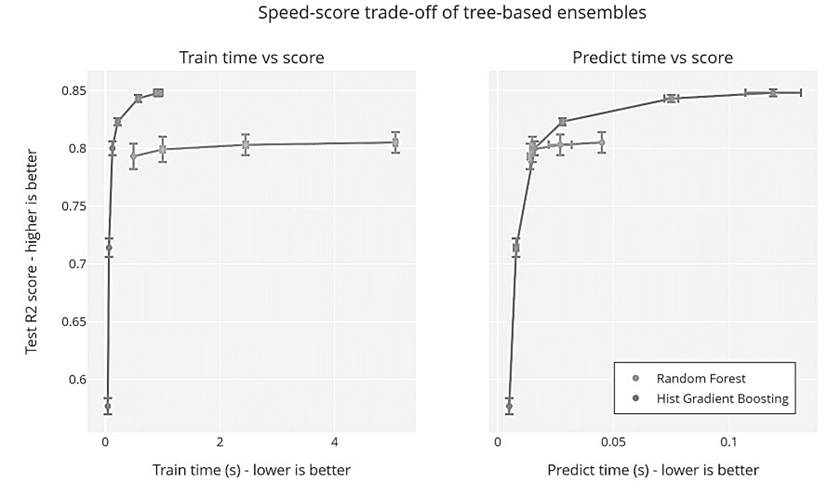
<div style="text-align: center;">图6-17  随机森林和HGBT模型性能的比较</div>

## <font color='blue' >6.8　堆叠泛化</font>

**堆叠（Stacking）泛化**是一种减小偏差的<font color='red'>组合估计器</font>。更准确地说，堆叠首先从**初始数据集**中训练多个**基学习器** $f_i(x)$，也称**初级学习器**，每个**初级学习器**的<font color='red'>输出</font>作为**次级学习器** $F$ 的<font color='red'>输入</font>，$F\left[f_1(x),f_2(x),\ldots,f_n(x) \right]$ ，可以理解为学习器嵌套，如图6-18所示。该**最终估计器**可以通过<font color='red'>交叉验证</font>进行训练。

**堆叠**类似**神经网络**，是一种**表征学习**。一般堆叠是两层结构，第一层<font color='red'>对原始数据提取特征</font>，第二层是<font color='red'>依据特征表示进行学习</font>的过程。将训练好的所有**基模型**<font color='red'>对训练样本进行预测</font>，第 $j$ 个基模型对第 $i$ 个训练样本的**预测值**将作为新的训练集中第 $i$ 个样本的第 $j$ 个**特征值**，最后学习器 $F$ 基于新的训练集进行训练。

StackingClassifier和StackingRegressor提供了这样的策略，可以应用于<font color='red'>分类</font>和<font color='red'>回归</font>问题。

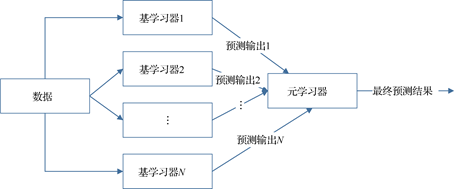
<div style="text-align: center;">图6-18  两层堆叠

**参数estimators**对应直接<font color='red'>处理</font>输入数据的并行堆叠在一起的<font color='red'>估计器的列表</font>，以<font color='red'>名称和估计器</font>组成<font color='red'>元组的列表形式</font>给出。

In [55]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.neighbors import KNeighborsRegressor
estimators = [('ridge', RidgeCV()), ('lasso', LassoCV(random_state=42)), ('knr', KNeighborsRegressor(n_neighbors=20, metric='euclidean'))]


定义第二层的学习器**final_estimator**和**StackingRegressor**对象**reg**。这里使用的**StackingClassifier**或**StackingRegressor**分别对应<font color='red'>分类器</font>或<font color='red'>回归器</font>。**StackingRegressor**()构造函数组合**estimators**和**final_estimator**，后前将前者的预测作为输入。

In [56]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
final_estimator = GradientBoostingRegressor(n_estimators=25, subsample=0.5, min_samples_leaf=25, max_features=1, random_state=42)
reg = StackingRegressor(estimators=estimators, final_estimator=final_estimator)


为了训练**estimators**和**final_estimator**，需要在训练数据上调用**fit()方法**。

In [57]:
from sklearn.datasets import load_diabetes
X, y = load_diabetes(return_X_y=True)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
reg.fit(X_train, y_train)


StackingRegressor(estimators=[('ridge', RidgeCV()),
                              ('lasso', LassoCV(random_state=42)),
                              ('knr',
                               KNeighborsRegressor(metric='euclidean',
                                                   n_neighbors=20))],
                  final_estimator=GradientBoostingRegressor(max_features=1,
                                                            min_samples_leaf=25,
                                                            n_estimators=25,
                                                            random_state=42,
                                                            subsample=0.5))

在训练过程中，使用**estimators**拟合**训练数据X_train**。训练结果将在调用方法**predict**()或**predict_proba**()时使用。

对于**StackingClassifier**，请注意，**estimators**的输出由**参数stack_method**控制，并且由每个估计器调用。该参数要么是一个字符串，即<font color='red'>估计器的方法名称</font>；要么是<font color='red'>'auto'</font>，将根据可用性自动识别方法，识别及测试顺序是**predict_proba()**、**decision_function**()和**predict()**。

**StackingRegressor**和**StackingClassifier**可以使用公布**predict**, **predict_proba**与**decision_function**方法的任何其他<font color='red'>回归器</font>或<font color='red'>分类器</font>。例如：

In [5]:
y_pred = reg.predict(X_test)
from sklearn.metrics import r2_score
print('R2 score: {:.2f}'.format(r2_score(y_test, y_pred)))


R2 score: 0.53


注意：也可以使用**transform()方法**来获得堆叠**estimators**的输出。

In [6]:
reg.transform(X_test[:5])

array([[142.36209608, 138.30724927, 146.1       ],
       [179.700576  , 182.89812552, 151.75      ],
       [139.89817956, 132.46803343, 158.25      ],
       [286.95180286, 292.65695767, 225.4       ],
       [126.88317154, 124.1215975 , 164.65      ]])

在实践中，一个**堆叠学习器**的预测效果至少和**最优基学习器**的预测效果一样好，但<font color='red'>训练堆叠预测器的时间复杂度较高</font>。  

通过将**final_estimator**分配给**StackingClassifier**或**StackingRegressor**可以实现多个堆叠层，如下面的堆叠层**final_estimator**由堆叠层**final_layer**定义。

In [58]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.neighbors import KNeighborsRegressor
final_layer_rfr = RandomForestRegressor(n_estimators=10, max_features=1, max_leaf_nodes=5,random_state=42)
final_layer_gbr = GradientBoostingRegressor(n_estimators=10, max_features=1, max_leaf_nodes=5,random_state=42)
final_layer = StackingRegressor(estimators=[('rf', final_layer_rfr),  ('gbrt', final_layer_gbr)], final_estimator=RidgeCV())
multi_layer_regressor = StackingRegressor(estimators=[('ridge', RidgeCV()), ('lasso', LassoCV(random_state=42)), ('knr', KNeighborsRegressor(n_neighbors=20, metric='euclidean'))], final_estimator=final_layer)
multi_layer_regressor.fit(X_train, y_train)

StackingRegressor(estimators=[('ridge', RidgeCV()),
                              ('lasso', LassoCV(random_state=42)),
                              ('knr',
                               KNeighborsRegressor(metric='euclidean',
                                                   n_neighbors=20))],
                  final_estimator=StackingRegressor(estimators=[('rf',
                                                                 RandomForestRegressor(max_features=1,
                                                                                       max_leaf_nodes=5,
                                                                                       n_estimators=10,
                                                                                       random_state=42)),
                                                                ('gbrt',
                                                                 GradientBoostingRegressor(max_features=1,
                                                                                           max_leaf_nodes=5,
                                                                                           n_estimators=10,
                                                                                           random_state=42))],
                                                    final_estimator=RidgeCV()))

In [15]:
print('R2 score: {:.2f}'.format(multi_layer_regressor.score(X_test, y_test)))

R2 score: 0.69


## <font color='blue' >6.9　概率校准</font>

在分类时，我们通常不仅希望预测类标签，还希望获得相应类标签的概率。这个概率会让我们对预测有一定的信心。有些模型可能会对类别概率给出较差的估计，有些甚至不支持概率预测。校准模块允许我们更好地校准给定模型的概率估计，或者添加对概率预测的支持。

经过良好校准的分类器是概率分类器，其**predict_proba()方法**的输出可以直接解释为<font color='red'>置信水平</font>。例如，一个校准良好的分类器对样本进行分类，使得在它给出接近0.8的predict_proba值的样本时，大约80%的样本实际上属于正类。

本章涉及的实践与前几章一样，主要使用**Scikit-learn**中提供的工具来实现。下面以示例的方式引入相关内容的讨论。


在展示如何重校准分类器之前，首先需要一种方法来检测分类器的校准效果。


概率预测的严格、合理的评分规则如**sklearn.metrics.brier_core_loss**和**sklearn.mmetrics.log_loss**，同时评估一个模型的校准能力和判别能力，以及数据的随机性。这源于Murphy著名的Brier得分分解。由于不清楚哪个项占主导地位，因此该得分仅用于评估校准（除非能计算出分解的每一项）。例如，一个较低的Brier损失并不一定意味着是一个校准更好的模型，这也可能意味着校准更差的模型具有更大的辨别能力，如该模型使用了更多特征。


### <font color='blue' >6.9.1  校准曲线</font>

校准曲线也称<font color='red'>可靠性图</font>。下面比较二分类器的概率预测的校准效果。例6-8在y轴上绘制了正标签的频率（更准确地说，是条件概率 $P$(Y=1|predict_proba) 的估计），在x轴上绘制了模型的预测概率 。棘手的部分是如何获取y轴上的值，在Scikit-learn中，这是通过对预测进行箱化实现的，使得x轴上表示的是每个箱子的平均预测概率。y轴是给定箱子的预测的阳性率，即其类别为正类的样本的比例。

例6-8 的结果如图6-19 所示，顶部校准曲线图由**CalibrationDisplay.from_estimator**()创建，它使用<font color='red'>calibration_curve()函数</font>来计算每个箱子的平均预测概率和阳性率。**CalibrationDisplay.from_estimator**()使用一个拟合的分类器作为输入，用于计算预测概率。因此，分类器必须具有<font color='red'>predict_proba()方法</font>。对于少数没有<font color='red'>predict_proba()方法</font>的分类器，可以使用<font color='red'>CalibratedClassifierCV类</font>将分类器输出校准为概率。

**例6-8：分类器校准比较。**

>本例的目标是比较 4 种分类模型（逻辑回归、高斯朴素贝叶斯、随机森林、线性SVM） 的 <font color='red'>概率校准</font>（probability calibration） 能力。  
<font color='red'>校准曲线</font>（Calibration Curve） 用于评估模型预测概率的可靠性（即预测概率是否接近真实概率）。  
<font color='red'>直方图</font>显示预测概率的分布，帮助分析模型是否倾向于过度自信或不自信。  
数据集是人工生成的二分类数据（100,000 个样本，20 个特征，仅 2 个信息性特征）。  

第一步，**生成数据集**。

>首先使用 <font color='red'>make_classification</font> 生成一个包含100000个样本和20个特征的二分类数据集。在20个特征中，只有2个是信息性的，2个是冗余的（信息性特征的随机组合），其余16个是无信息的（随机数）噪声。在这100000个样本构成的训练集中，100个样本（模拟小样本场景）用于训练，其余用于测试。  
>数据拆分时关闭 shuffle，确保训练集是前 100 个样本。

In [67]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=100_000, n_features=20, n_informative=2, n_redundant=2, random_state=42)

train_samples = 100  # 用于训练模型的样本数
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=100_000 - train_samples,)


第二步，**校准曲线**。

>下面使用**训练集**训练4个模型中的每一个，并使用**测试集的预测概率**绘制<font color='red'>校准曲线</font>。  
>**1. 定义分类器**  
>- 逻辑回归（LogisticRegression）：  
天然输出校准概率（基于逻辑函数）。  
>- 高斯朴素贝叶斯（GaussianNB）：  
假设特征独立，概率估计可能不准。  
>- 线性SVM（LinearSVC）：  
默认无 predict_proba，需手动缩放 decision_function 到 [0,1]（NaivelyCalibratedLinearSVC）。  
>- 随机森林（RandomForestClassifier）：  
基于投票比例输出概率，可能过于自信。  

>**2.绘制校准曲线和直方图**  
>- 校准曲线：  
将预测概率分 10 个箱（n_bins=10），计算每个箱的 <font color='red'>平均预测概率</font> 和 <font color='red'>真实阳性率</font>。  
理想校准曲线应为对角线（预测概率 = 真实概率）。  
>- 直方图：  
显示每个模型预测概率的分布（是否偏向 0 或 1）。更具体地说，显示的是每个预测概率箱子中的样本数量

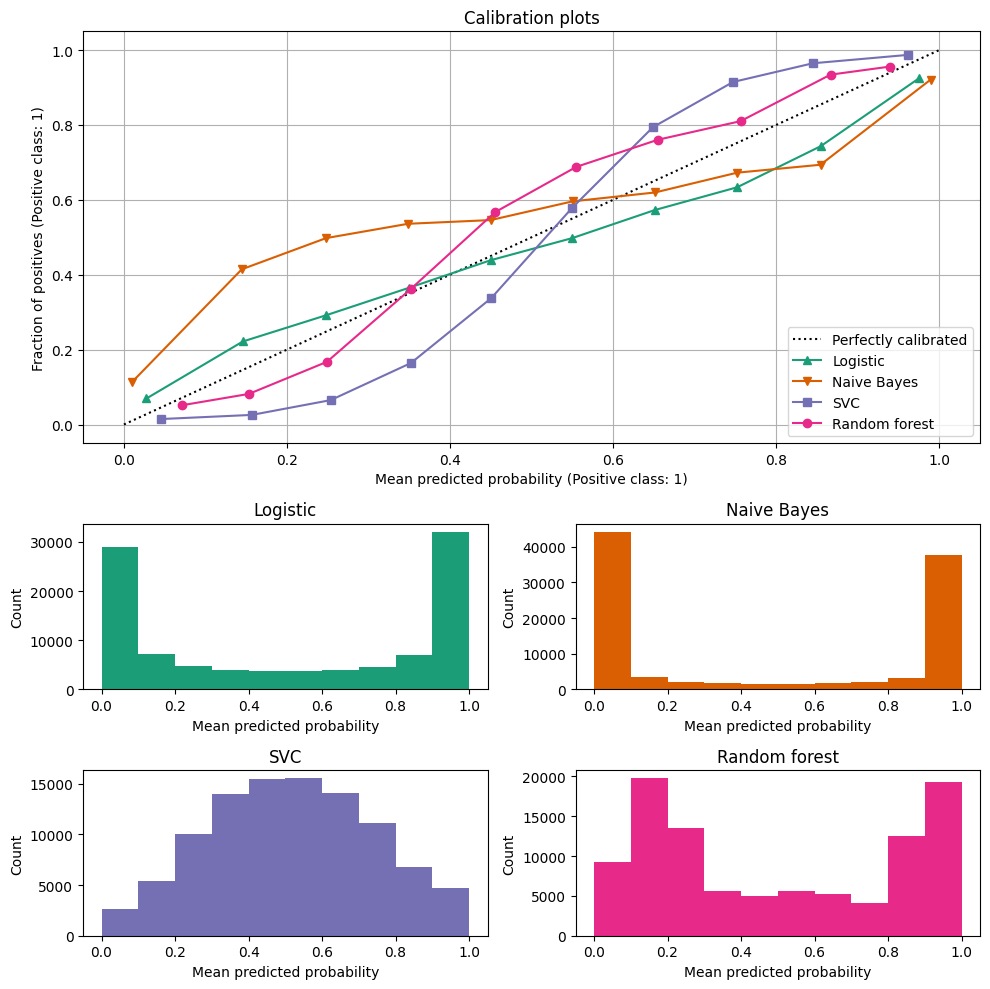

In [68]:
import numpy as np
from sklearn.svm import LinearSVC


class NaivelyCalibratedLinearSVC(LinearSVC):
    """LinearSVC 具有 `predict_proba` 方法，很自然的缩放 `decision_function` 输出"""

    def fit(self, X, y):
        super().fit(X, y)
        df = self.decision_function(X)
        self.df_min_ = df.min()
        self.df_max_ = df.max()

    def predict_proba(self, X):
        """Min-max 缩放 `decision_function` 的输出到 [0,1]"""
        df = self.decision_function(X)
        calibrated_df = (df - self.df_min_) / (self.df_max_ - self.df_min_)
        proba_pos_class = np.clip(calibrated_df, 0, 1)
        proba_neg_class = 1 - proba_pos_class
        proba = np.c_[proba_neg_class, proba_pos_class]
        return proba

from sklearn.calibration import CalibrationDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# 构建分类器
lr = LogisticRegression()
gnb = GaussianNB()
svc = NaivelyCalibratedLinearSVC(C=1.0, dual="auto")
rfc = RandomForestClassifier()

clf_list = [(lr, "Logistic"), (gnb, "Naive Bayes"), (svc, "SVC"), (rfc, "Random forest"),]

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
markers = ["^", "v", "s", "o"]
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(clf, X_test, y_test, n_bins=10, name=name, ax=ax_calibration_curve, color=colors(i), marker=markers[i],)
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots")

# 添加直方图
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(calibration_displays[name].y_prob, range=(0, 1), bins=10, label=name, color=colors(i),)
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()


<div style="text-align: center;">图6-19  分类器校准比较

>**结果解析**
> 
>**1. 校准曲线分析**  
| 模型 | 校准表现 | 原因 |
| :--- | :--- | :--- |
| 逻辑回归 | 接近理想对角线 | 概率模型，输出自然校准。 | 
| 高斯朴素贝叶斯	| 概率低估（曲线低于对角线） | 独立性假设不成立，导致概率压缩。 | 
| 线性SVM | 极端概率（靠近 0 或 1） | decision_function 缩放后仍过于自信。 | 
| 随机森林 | S 形曲线（过度自信） | 投票机制导致概率偏向 0 或 1。 | 

>**2. 直方图分析**  
| 模型 | 预测概率分布 | 问题 |
| :--- | :--- | :--- |
| 逻辑回归 | 较均匀分布 | 无显著偏差。 | 
| 高斯朴素贝叶斯	| 集中在中间值（0.5 附近） | 概率低估。 | 
| 线性SVM | 两极分化（0 或 1） | 无法输出中间概率。 | 
| 随机森林 | 两极分化（0 或 1） | 投票机制导致“非黑即白”。 |   

>**3. 关键结论**  
<font color='red'>逻辑回归</font> 是唯一校准良好的模型，适合需要可靠概率的场景（如医疗诊断）。  
<font color='red'>随机森林/SVM</font> 需后处理校准（如 Platt Scaling 或 Isotonic Regression）。  
<font color='red'>朴素贝叶斯</font> 需调整先验或使用校准方法。  

图6-19 的底部直方图通过显示在每个预测概率箱子中的样本数量可以深入了解每个分类器的行为。  

**LogisticRegression**()在默认情况下返回校准良好的预测，由于它直接<font color='red'>优化Log-损失</font>。与此相反，其他模型返回了具有不同偏差的概率。  

**朴素贝叶斯**<font color='red'>倾向于将概率推至0或1</font>（注意直方图中的计数）。这主要是因为在给定类别的情况下，当特征是条件独立的假设成立时，朴素贝叶斯方程可提供概率的正确估计。然而，特征往往是正相关的，本数据集就是这样，它包含两个作为信息特征的随机线性组合生成的特征。这些相关特征被有效地计数两次，从而将预测概率推至0或1。 

为了显示出**LinearSVC**的性能，这里通过应用最小-最大缩放将**decision_function**()的输出缩放为[0,1]，因为SVC默认不输出概率。LinearSVC显示了比**RandomForestClassifier**更为Sigmoid形的曲线，这对最大距离（Maximum-Margin）方法来说是典型的，因为lineSVC专注于接近决策边界的难以分类的样本（支持向量）。

**RandomForestClassifier**显示了相反的行为：直方图显示概率约在0.2和0.9处为峰值，而接近0或1的概率非常罕见。因此，校准曲线显示出特征性的Sigmoid形，并且返回的概率通常接近0或1。

### <font color='blue' >6.9.2   校准分类器</font>

通过<font color='red'>拟合</font>一个**回归器**（也称校准器）实现<font color='red'>校准</font>一个**分类器**，该回归器将<font color='red'>分类器的输出</font>（由方法decision_function()或predict_proba()给出）**映射**到$[0,1]$中的<font color='red'>校准概率</font>。对于一个给定的样本，使用 $f_i$ 表示分类器输出，校准器试图预测条件事件概率 $P\left(y_i=1\mid f_i\right)$ 。

在理想情况下，**校准器**在一个数据集上被<font color='red'>拟合</font>，而该数据集独立于最初用于拟合分类器的训练数据。这是因为分类器在其训练数据上的性能将优于新数据。因此，使用训练数据的分类器输出拟合校准器将导致有偏差的校准器，该校准器映射到比它应该映射的概率更接近0和1。

在Scikit-learn中，通常使用**CalibratedClassifierCV类**实现一个**校准分类器**。**CalibratedClassifierCV类**使用<font color='red'>交叉验证方法</font>来确保始终使用**无偏数据**来<font color='red'>拟合校准器</font>。数据集被拆分成k个(train_set，test_set)对，由**参数cv**确定。当设置<font color='red'>ensemble=True</font>（默认值）时，对每个交叉验证拆分独立重复以下过程：首先在训练子集上训练**base_estimator**的一份副本；然后，在测试子集上的预测被用来拟合校准器（或者为Sigmoid回归器，或者为isotonic回归器）。这导致k个(classifier, calibrator)耦合组成的集合中的每个校准器都将其相应分类器的输出映射到$[0,1]$。每个耦合都在**calibrated_classifiers_属性**中描述，其中每一项都是可以输出校准概率的具有**predict_proba()方法**的校准分类器。**主calibrated_ClassierCV**实例对应在**calibrated_classiers_列表**中<font color='red'>k个估计器的预测概率的平均值</font>。**predict()方法**的输出是具有<font color='red'>最高概率</font>的那个类别。

当**ensemble=False**时，通过<font color='red'>方法cross_val_predict()</font>，交叉验证可获得所有数据的无偏预测，使用这些无偏预测训练校准器。<font color='red'>属性calibrated_classifiers_</font>仅由一对(classifier, calibrator)组成，其中的**分类器**是在所有数据上训练的**base_estimator**。在这种情况下，**CalibratedClassifierCV类**的**predict_proba()的输出**是从单个(classifier, calibrator)对获得的<font color='red'>预测概率</font>。

设置**ensemble=True**的主要优点是受益于传统的集成效应，类似于Bagging元估计器，所得<font color='red'>到的集成结果应该都经过了较好的校准</font>，并且比设置ensemble=False时的结果稍微准确一些。设置**ensemble=False**的主要优点是其计算性，它<font color='red'>通过只训练单个基分类器和校准器对来减少总体拟合时间</font>，<font color='red'>减小最终模型的大小并加快预测速度</font>。

CalibratedClassifierCV类通过设置method参数取值为"sigmoid"或" isotonic "来支持使用两种回归技术进行校准。

**1．Sigmoid回归**

通过设置<font color='red'>method="sigmoid" </font>使用**sigmoid回归器**，它是基于Platt的逻辑模型：

$p\left(y_i=1\mid f_i\right)=\frac{1}{1+\exp(Af_i+B)}$

其中， $y_i$ 是样本 $i$ 的真实标签； $f_i$ 是样本 $i$ 经未校准分类器的输出； $A$ 和 $B$ 是通过最大似然拟合回归器时要确定的实数。


<font color='red'>sigmoid()方法</font>假设通过将**Sigmoid函数**应用于原始预测来校正校准曲线。在各种基准数据集上，针对具有公共核函数的**SVM**，这一假设已在经验上得到证明，但在一般情况下并不一定成立。

**2．Isotonic回归**

通过设置method="isotonic" 拟合一个非参数保序回归器，该回归器输出一个逐步非递减函数，详见sklearn.isotonic。通过最小化 $\sum_{i=1}^{n} (y_i-\widehat{f}_i)^2$ ，当 $f_i \geq f_j$时，有 $\widehat{f}_i \geq \widehat{f}_j$ 。其中， $y_i$ 是样本 $i$ 的真实标签， $\widehat{f}_i$ 是样本 $i$ 校准分类器的输出（校准概率）。与Sigmoid回归相比，这种方法更通用，因为其唯一的限制是映射函数单调递增。因此，它更强大，因为它可以校正未校准模型的任何单调失真。然而，它更容易过拟合，尤其在小数据集上。总的来说，当有足够的数据（大于约1000个样本）来避免过拟合时，Isotonic回归的性能表现将与Sigmoid回归的表现一样好或更好。

分类时，人们通常不仅想要预测类别标签，还想要预测相关联的概率。这种概率体现了预测的可信度。例6-9 演示了如何使用校准曲线来可视化预测概率的校准效果，包括展示未校准的分类器的结果，如图6-20 所示。

**例6-9：概率校准曲线。**

>本例的目标是 比较<font color='red'>高斯朴素贝叶斯</font>（GaussianNB）在概率校准前后的表现，并验证 校准方法（Isotonic 和 Sigmoid）的有效性。  
逻辑回归（LogisticRegression） 作为基线模型（通常校准良好）。  
未校准的 GaussianNB 作为对比，观察其概率偏差。  
校准后的 GaussianNB（使用 CalibratedClassifierCV 的 isotonic 和 sigmoid 方法）展示校准效果。  
数据集为 人工生成的二分类数据（100,000 个样本，20 个特征，2 个信息性特征，10 个冗余特征）。  

第一步，**构建数据集**。

>这里使用 <font color='red'>make_classification</font> 生成一个包含100000个样本和20个特征的合成二分类数据集。  
>在20个特征中，只有2个是信息性的，10个是冗余的（信息性特征的随机组合），其余8个是无信息的（随机数）。  
>在100000个样本中，1000个用于训练，其余99,000 个用于测试。  
>通过 test_size=0.99 实现不均衡拆分，模拟小训练集场景。  

In [69]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=100_000, n_features=20, n_informative=2, n_redundant=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.99, random_state=42)


第二步，**校准曲线**。

>这里通过比较<font color='red'>逻辑回归</font>和<font color='red'>有/无校准GaussianNB()方法</font>的校准效果来说明校准的有效性和必要性。  
>（1）**LogisticRegression**：用作基线，通常情况下使用对数损失，正确地正则化逻辑回归在默认情况下得到了很好的校准。    
（2）未校准版本：直接使用 **GaussianNB()**。    
（3）**Isotonic**和**Sigmoid校准GaussianNB()**。  

>**绘制校准曲线和直方图**  
**校准曲线**：  
>- 将预测概率分 10 个箱（n_bins=10），计算<font color='red'>每个箱子的平均预测概率（x 轴）</font> 和 <font color='red'>每个箱子中正类的比率（y 轴）</font>。  
理想情况下，曲线应接近对角线（预测概率 = 真实概率）。

>**直方图**：  
>- 显示每个模型预测概率的分布，观察是否偏向极端值（0 或 1）或中间值（0.5）。  

下面的代码片段绘制了这4种情况下的校准曲线，如图6-20 所示。

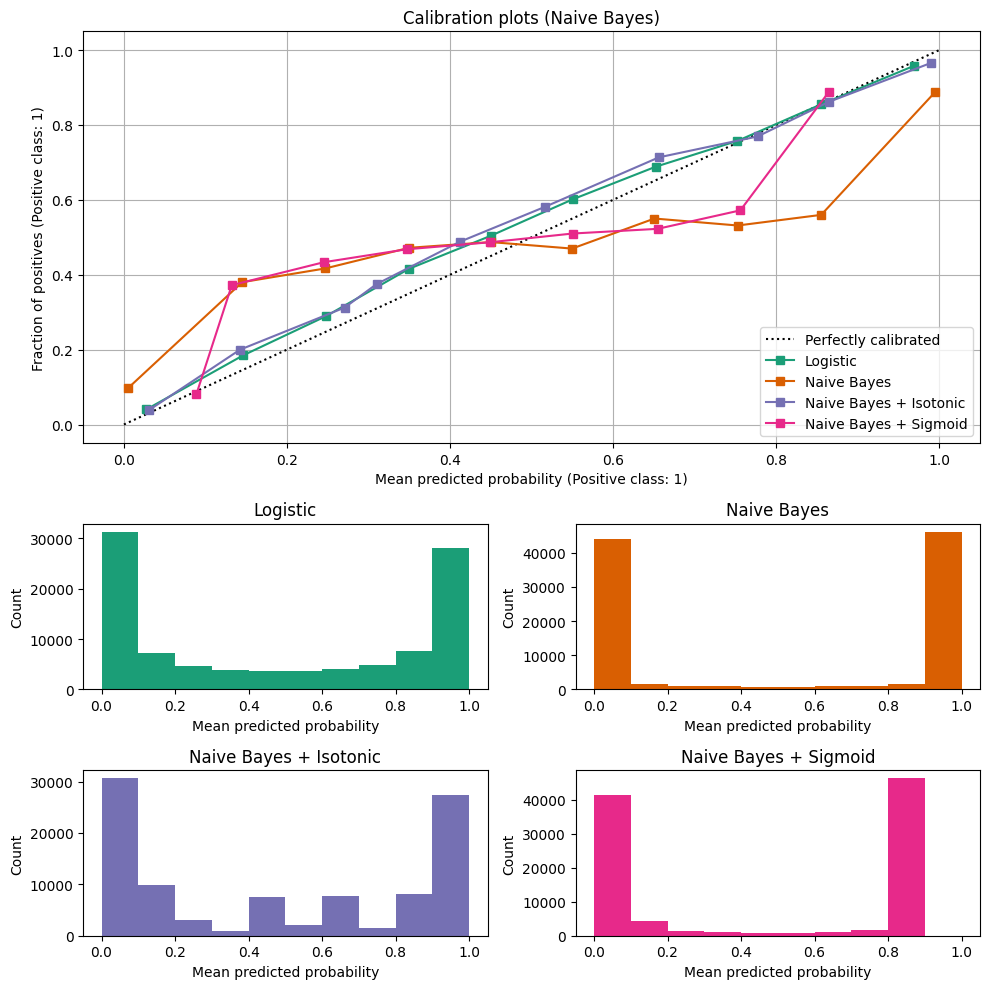

In [3]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

lr = LogisticRegression(C=1.0)
gnb = GaussianNB()
gnb_isotonic = CalibratedClassifierCV(gnb,cv=2,method="isotonic")
gnb_sigmoid = CalibratedClassifierCV(gnb, cv=2, method="sigmoid")

clf_list=[
 (lr, "Logistic"),
 (gnb, "Naive Bayes"),
 (gnb_isotonic, "Naive Bayes + Isotonic"), 
 (gnb_sigmoid, "Naive Bayes + Sigmoid"),]
fig = plt.figure(figsize=(10, 10))
gs = GridSpec(4, 2)
colors = plt.get_cmap("Dark2")

ax_calibration_curve = fig.add_subplot(gs[:2, :2])
calibration_displays = {}
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    display = CalibrationDisplay.from_estimator(clf, X_test, y_test, n_bins=10, name=name, ax=ax_calibration_curve, color=colors(i),)
    calibration_displays[name] = display

ax_calibration_curve.grid()
ax_calibration_curve.set_title("Calibration plots (Naive Bayes)")

# 添加直方图
grid_positions = [(2, 0), (2, 1), (3, 0), (3, 1)]
for i, (_, name) in enumerate(clf_list):
    row, col = grid_positions[i]
    ax = fig.add_subplot(gs[row, col])

    ax.hist(calibration_displays[name].y_prob, range=(0, 1), bins=10, label=name, color=colors(i),)
    ax.set(title=name, xlabel="Mean predicted probability", ylabel="Count")

plt.tight_layout()
plt.show()

>**结果解析**  
>**1. 校准曲线分析**  
| 模型 | 校准表现	| 原因 | 
| :--- | :--- |  :--- |
| LogisticRegression | 接近对角线 | 逻辑回归本身输出校准概率。 | 
| 未校准 GaussianNB	| 曲线低于对角线（概率低估） | 独立性假设不成立，导致概率压缩。 | 
| GaussianNB + Isotonic	| 接近对角线	| 分段线性校准修正了朴素贝叶斯的偏差。 | 
| GaussianNB + Sigmoid	| 接近对角线（略逊于 Isotonic） | Platt Scaling 对单调偏差有效，但不如 Isotonic 灵活。 | 

>**2. 直方图分析**  
| 模型 | 预测概率分布 | 问题 | 
| :--- | :--- |  :--- |
| LogisticRegression | 较均匀分布 | 无显著偏差。 | 
| 未校准 GaussianNB	| 集中在中间值（0.5 附近） | 概率低估，缺乏置信度。 | 
| GaussianNB + Isotonic	| 分布更均匀 | 校准后概率更接近真实分布。 | 
| GaussianNB + Sigmoid	| 分布略偏两端	Sigmoid | 校准对极端值更敏感。 | 

>**3. 关键结论**  
<font color='red'>逻辑回归</font> 是天然校准的模型，适合直接输出概率。  
<font color='red'>朴素贝叶斯</font> 需校准（尤其是小数据集时），<font color='red'>Isotonic</font> 校准效果优于 <font color='red'>Sigmoid</font>。  
校准方法选择：  
数据量大且单调偏差 → Sigmoid（计算量小）。  
数据量小或复杂偏差 → Isotonic（更灵活）。  

<div style="text-align: center;">图6-20  概率校准曲线

由图6-20 的上子图可知，未校准的<font color='red'>GaussianNB()</font>由于冗余特征而校准不良，这些冗余特征违反了特征独立性的假设，导致一个过于自信的分类器，由典型的<font color='red'>倒置Sigmoid形曲线</font>表示。从几乎为对角线的校准曲线可以看出，用<font color='red'>Isotonic回归</font>校准<font color='red'>GaussianNB()的概率</font>可以解决这个问题。**Sigmoid回归**也略微改善了校准，尽管不如**非参数Isotonic回归**那么强烈。这归因于我们有大量的校准数据，从而可以利用非参数模型更高的灵活性。

下面考虑几个分类指标，进行定量分析：Brier评分损失、Log损失、精确率、召回率、F1-score和ROC AUC。

In [26]:
from collections import defaultdict
import pandas as pd
from sklearn.metrics import (brier_score_loss, f1_score, log_loss, precision_score, recall_score, roc_auc_score,)

scores = defaultdict(list)
for i, (clf, name) in enumerate(clf_list):
    clf.fit(X_train, y_train)
    y_prob = clf.predict_proba(X_test)
    y_pred = clf.predict(X_test)
    scores["Classifier"].append(name)

    for metric in [brier_score_loss, log_loss, roc_auc_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_prob[:, 1]))

    for metric in [precision_score, recall_score, f1_score]:
        score_name = metric.__name__.replace("_", " ").replace("score", "").capitalize()
        scores[score_name].append(metric(y_test, y_pred))

    score_df = pd.DataFrame(scores).set_index("Classifier")
    score_df.round(decimals=3)
score_df


,Brier loss,Log loss,Roc auc,Precision,Recall,F1
Classifier,,,,,,
Logistic,0.098932,0.323200,0.937443,0.871965,0.851348,0.861533
Naive Bayes,0.117608,0.782755,0.940373,0.857400,0.875941,0.866571
SVC,0.144943,0.465660,0.937597,0.872186,0.851792,0.861868
Random forest,0.098438,0.414787,0.937726,0.872139,0.842625,0.857128


输出结果如上。

注意：尽管校准改善了**Brier评分损失**（由校准项和细化项组成的指标）和**Log损失**，但不会显著改变<font color='red'>预测准确性指标</font>（精确率、召回率和F1分数）。这是因为校准不应显著改变在决策阈值位置处（在图6-21 的 $x=\frac1 2$ 处）的预测概率。然而，校准应该使预测的概率更加准确，从而对在不确定性下做出分配决策更加有用。此外，ROC AUC根本不应该改变，因为校准是单调变换的。事实上，没有等级指标受到校准的影响。

**例6-10** 说明了**Sigmoid回归校准**如何<font color='red'>改变三分类问题的预测概率</font>。图6-21 展示的是标准的二维单纯形，其中3个角分别对应3个类。箭头从未校准分类器预测的概率向量指向由同一分类器预测的Sigmoid回归校准后的概率向量。颜色表示实例的真实类（红色：类1，绿色：类2，蓝色：类3）。

**例6-10：三分类的概率校准。**

>本例的目标是 **比较随机森林分类器在三分类任务中的概率校准效果**，重点分析：  
>- **未校准的随机森林**：直接输出预测概率（可能过于自信）。  
>- **校准后的随机森林**：使用 <font color='red'>CalibratedClassifierCV</font> 的 <font color='red'>sigmoid</font> 方法调整概率。  
>- **可视化概率变化**：通过<font color='red'>二维单纯形图（Simplex Plot）</font>展示校准前后概率的调整方向。  

>这里生成一个包含2000个样本、2个特征和3个目标类的分类数据集，并将数据拆分如下：    
>- 训练：600个样本（用于训练分类器）。   
>- 验证：400个样本（用于校准预测概率）。   
>- 测试：1000个样本。  

请注意，这里还创建了由**X_train_valid**和**y_train_valid**组成的数据集，它们由训练和验证子集组成。当我们只想训练分类器而不想校准预测概率时，就会使用这种方法。  


第一步，**生成数据**。


>使用 <font color='red'>make_blobs</font>  生成 2,000 个样本，2 个特征，3 个类别（centers=3），类别间标准差为 5.0（增加分类难度）。  
数据拆分：  
>- 训练集：600 样本（训练模型）。  
>- 验证集：400 样本（校准概率）。  
>- 测试集：1,000 样本（评估校准效果）。  
<font color='red'>X_train_valid</font> 和 <font color='red'>y_train_valid</font> 是训练集 + 验证集（用于训练未校准模型）。  

In [61]:
import numpy as np
from sklearn.datasets import make_blobs

np.random.seed(0)

X, y = make_blobs(n_samples=2000, n_features=2, centers=3, random_state=42, cluster_std=5.0)
X_train, y_train = X[:600], y[:600]
X_valid, y_valid = X[600:1000], y[600:1000]
X_train_valid, y_train_valid = X[:1000], y[:1000]
X_test, y_test = X[1000:], y[1000:]


第二步，拟合并校准。  


>首先，在训练集和验证（1000个样本）上训练一个具有25个基估计器（树）的**随机森林分类器**，这是<font color='red'>未校准</font>的分类器。


In [62]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=25)
clf.fit(X_train_valid, y_train_valid)


RandomForestClassifier(n_estimators=25)

>为了训练<font color='red'>校准的分类器</font>，这里从<font color='red'>相同的随机森林分类器</font>开始，但仅使用训练数据子集（600个样本）对其进行训练。然后在两阶段过程中使用验证数据子集（400个样本），使用<font color='red'>method='sigmoid'</font>进行校准。  
>- <font color='red'>method="sigmoid"</font>：使用 Platt Scaling（逻辑回归拟合概率）。  
>- <font color='red'>cv="prefit"</font>：表示模型已预训练，仅需校准。  

In [64]:
from sklearn.calibration import CalibratedClassifierCV

clf = RandomForestClassifier(n_estimators=25)
clf.fit(X_train, y_train)
cal_clf=CalibratedClassifierCV(clf,method="sigmoid",cv="prefit")
cal_clf.fit(X_valid, y_valid)


C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\calibration.py:337: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=RandomForestClassifier(n_estimators=25))

第三步，**概率比较**。

>下面绘制一个带有箭头的<font color='red'>二维单纯形图</font>，显示测试样本的<font color='red'>预测概率的变化</font>。  

>**二维单纯形图**：  
三分类概率空间被压缩到二维平面（因概率和为 1）。  
每个测试样本的预测概率表示为点 (p₁, p₂)，其中 p₃ = 1 - p₁ - p₂。  
>- <font color='red'>箭头</font>：从校准前的概率指向校准后的概率，颜色表示真实类别。  
>- <font color='red'>顶点</font>：完美预测点（如 (1,0,0) 表示类别 1 的确定性预测）。  
>- <font color='red'>网格线</font>：辅助观察概率分布。  

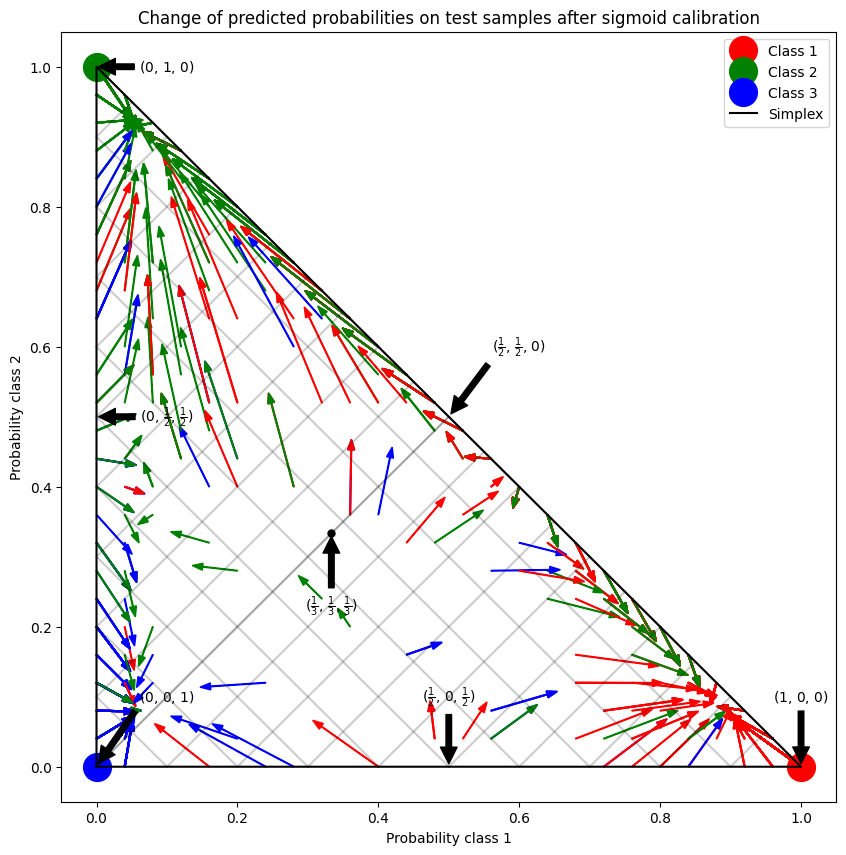

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
colors = ["r", "g", "b"]

clf_probs = clf.predict_proba(X_test)
cal_clf_probs = cal_clf.predict_proba(X_test)
# 绘制箭头
for i in range(clf_probs.shape[0]):
    plt.arrow(
        clf_probs[i, 0], clf_probs[i, 1],
        cal_clf_probs[i, 0] - clf_probs[i, 0], cal_clf_probs[i, 1] - clf_probs[i, 1],
        color=colors[y_test[i]],
        head_width=1e-2,)

# 在每个顶点处绘制完美的预测
plt.plot([1.0], [0.0], "ro", ms=20, label="Class 1")
plt.plot([0.0], [1.0], "go", ms=20, label="Class 2")
plt.plot([0.0], [0.0], "bo", ms=20, label="Class 3")

# 绘制单元单纯形的边界
plt.plot([0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], "k", label="Simplex")

# 注释单纯形周围的6个点和单纯形内部中点
plt.annotate(
    r"($\frac{1}{3}$, $\frac{1}{3}$, $\frac{1}{3}$)",
    xy=(1.0 / 3, 1.0 / 3), xytext=(1.0/3, 0.23),xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.plot([1.0 / 3], [1.0 / 3], "ko", ms=5)
plt.annotate(
    r"($\frac{1}{2}$, $0$, $\frac{1}{2}$)",
    xy=(0.5, 0.0), xytext=(0.5, 0.1), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.annotate(
    r"($0$, $\frac{1}{2}$, $\frac{1}{2}$)",
    xy=(0.0, 0.5), xytext=(0.1, 0.5), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.annotate(
    r"($\frac{1}{2}$, $\frac{1}{2}$, $0$)",
    xy=(0.5, 0.5), xytext=(0.6, 0.6), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.annotate(
    r"($0$, $0$, $1$)",
    xy=(0, 0), xytext=(0.1, 0.1), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.annotate(
    r"($1$, $0$, $0$)",
    xy=(1, 0), xytext=(1, 0.1), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
plt.annotate(
    r"($0$, $1$, $0$)",
    xy=(0, 1), xytext=(0.1, 1), xycoords="data",
    arrowprops=dict(facecolor="black", shrink=0.05),
    horizontalalignment="center", verticalalignment="center",)
# 添加网格
plt.grid(False)
for x in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    plt.plot([0, x], [x, 0], "k", alpha=0.2)
    plt.plot([0, 0 + (1-x)/2], [x,x + (1-x)/2], "k", alpha=0.2)
    plt.plot([x, x + (1-x)/2], [0,0 + (1-x)/2], "k", alpha=0.2)

plt.title("Change of predicted probabilities on test samples after sigmoid calibration")
plt.xlabel("Probability class 1")
plt.ylabel("Probability class 2")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
_ = plt.legend(loc="best")


<div style="text-align: center;">图6-21  概率校准曲线

>**结果解析**  
>**1. 校准效果**  
>- <font color='red'>未校准随机森林</font>：  
概率可能偏向极端值（如 (0.9, 0.1, 0)），反映模型的过度自信。  
>- <font color='red'>校准后随机森林</font>：  
箭头显示概率向中间区域（如 (1/3, 1/3, 1/3)）调整，修正了过度自信的问题。  
<font color='red'>Sigmoid 校准</font> 使概率更接近真实分布，尤其是对边界样本（概率接近 0.5 的样本）。  

>**2. 单纯形图关键点**  
| 点坐标 | 含义 | 校准方向 | 
| :--- | :--- |  :--- |
| (1,0) | 100% 类别 1 | 校准后概率可能降低（若模型过于自信）。 | 
| (0,1) | 100% 类别 2 | 同上。 | 
| (0,0)	| 100% 类别 3 | 同上。 | 
| (1/3,1/3)	| 均匀分布（三类概率相等） | 校准可能小幅调整。 | 

>**3. 颜色分类**  
<font color='red'>红色</font>（Class 1）、<font color='green'>绿色</font>（Class 2）、<font color='blue'>蓝色</font>（Class 3）：  
箭头颜色表示真实类别，可观察不同类别的校准趋势。  

在图6-21 中，单纯形的每个<font color='red'>顶点</font>都表示一个<font color='red'>完美预测的类</font>（如1,0,0）。<font color='red'>单纯形内部的中点</font>表示以相等的概率（1/3,1/3,1/3）预测3个类别。每个箭头从未校准的概率开始，至校准后的概率结束。箭头的颜色表示<font color='red'>该测试样本的真实类别</font>。  


未校准分类器对其预测过于自信，并导致大的**Log损失**。由于两个因素，校准分类器产生较小的Log损失。首先，请注意图6-21 中的箭头通常指向远离单纯形的边缘，至少其中一个类的概率为0。其次，很大一部分箭头指向真实类，如绿色箭头（真实类为“绿色”的样本）通常指向绿色顶点。这导致正确类别的预测概率增加。因此，经过校准的分类器产生了更准确的预测概率，从而导致更小的Log损失。



可以通过比较未校准和校准分类器对1000个测试样本的预测Log损失来客观地表明这一点。请注意，另一种选择是增加<font color='red'>随机森林分类器的基估计器（树）</font>的数量，这将导致类似的Log损失减小。

In [6]:
from sklearn.metrics import log_loss

score = log_loss(y_test, clf_probs)
cal_score = log_loss(y_test, cal_clf_probs)

print("Log-loss of")
print(f" * uncalibrated classifier: {score:.3f}")
print(f" * calibrated classifier: {cal_score:.3f}")


Log-loss of
 * uncalibrated classifier: 1.410
 * calibrated classifier: 0.536


输出结果如上。

最后，在二维单纯形上生成一个可能的<font color='red'>未校准概率的网格</font>，计算相应的<font color='red'>校准概率</font>，并为每个<font color='red'>概率绘制箭头</font>。箭头按照<font color='red'>最高未校准概率</font>着色。图6-22展示了学习的校准图。

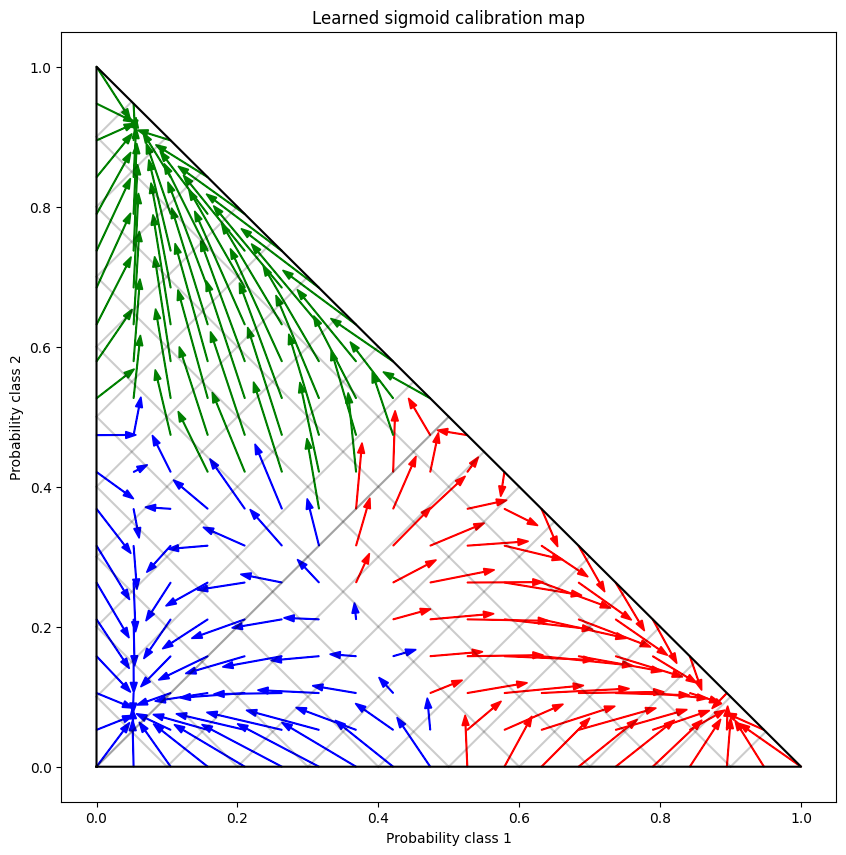

In [13]:
plt.figure(figsize=(10, 10))
# 生成概率值网格
p1d = np.linspace(0, 1, 20)
p0, p1 = np.meshgrid(p1d, p1d)
p2 = 1 - p0 - p1
p = np.c_[p0.ravel(), p1.ravel(), p2.ravel()]
p = p[p[:, 2] >= 0]

# 用3个类别的校准器来计算校准概率
calibrated_classifier = cal_clf.calibrated_classifiers_[0]
prediction = np.vstack([calibrator.predict(this_p) for calibrator, this_p in zip(calibrated_classifier.calibrators, p.T)]).T

#重标准化校准预测，确保它们保持在单纯形内。重标准化步骤是通过 CalibratedClassifierCV类在多类问题上的predict()方法在内部执行。
prediction /= prediction.sum(axis=1)[:, None]

# 绘制校准器引起的预测概率变化
for i in range(prediction.shape[0]):
    plt.arrow(
        p[i, 0], p[i, 1],
        prediction[i, 0] - p[i, 0], prediction[i, 1] - p[i, 1],
        head_width=1e-2,
        color=colors[np.argmax(p[i])],  )

# 绘制单位单纯形的边界
plt.plot([0.0, 1.0, 0.0, 0.0], [0.0, 0.0, 1.0, 0.0], "k", label="Simplex")

plt.grid(False)
for x in [0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0]:
    plt.plot([0, x], [x, 0], "k", alpha=0.2)
    plt.plot([0, 0 + (1-x)/2], [x, x + (1-x)/2], "k", alpha=0.2)
    plt.plot([x, x + (1-x)/2], [0, 0 + (1-x)/2], "k", alpha=0.2)

plt.title("Learned sigmoid calibration map")
plt.xlabel("Probability class 1")
plt.ylabel("Probability class 2")
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.show()


<div style="text-align: center;">图6-22  校准后曲线

## <font color='blue' >6.10　本章小结

本章自**偏差**与**方差**展开讨论，引入了**集成策略**及其步骤，使读者能够初步了解各算法及其特点，也基本知道了哪些场景可以使用哪些方法，以及各算法的优化要素组成。自简入繁地讲解**串联的Boosting**、**并行的Bagging**，以及**嵌套式/层级结构的堆叠**等集成算法框架。虽然书中尽可能给出每种方法的基本理论、拓展，但本书更多聚焦于其工程实践和使用技巧。

## <font color='blue' >课后习题

>1．什么是集成学习？集成学习的步骤和分类是怎样的？


>2．集成学习中的偏差和方差有什么不同？论述两者间的关系。

>3．选择一个数据集，遵循集成学习的步骤，分别使用随机森林、AdaBoost、GBDT、HGBT等算法构建模型并进行训练，比较各算法的优劣。

>4．针对第5章和第6章中的各种机器方法，实现校准比较并绘制相应的校准曲线。
